In [2]:
"imports"
import functions
import Interp3Dfield as tt
from neuron import h, gui
import numpy as np
import time
import datetime
import matplotlib.pyplot as plt
import scipy.io as sio
import os
import seaborn as sb
from matplotlib.colors import LinearSegmentedColormap
import mat73
from skimage import measure
import meshio
import gmsh
import trimesh
import stl
from scipy.spatial import cKDTree
import open3d as o3d
import pickle
from scipy.stats import ttest_ind, f_oneway, wilcoxon, shapiro, anderson, skew, variation, pearsonr, spearmanr, mannwhitneyu, linregress, chisquare
import pprint

	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	0 
	1 
Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
"loading in head model"
subject = 3
direction = 'lateral'
freq = '300Hz'


name = rf"Exyz\s{subject}_{freq}.mat"
matf = mat73.loadmat(name)

330 429 488


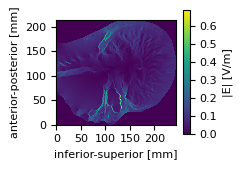

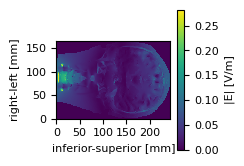

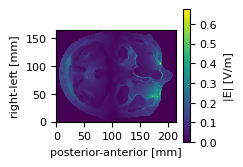

In [ ]:
"plotting E-field distribution"
#print(matf.keys())
Exlat, Eylat, Ezlat = matf['E'][direction]['x'], matf['E'][direction]['y'], matf['E'][direction]['z']
Emaglat = np.sqrt(Exlat**2+Eylat**2+Ezlat**2)[:,:,:]
lenx, leny, lenz = Emaglat.shape
print(lenx,leny,lenz)

plt.imshow(Emaglat[lenx//2,:,:],extent=[0,lenz*0.5,0,leny*0.5], interpolation='nearest') #
cbar = plt.colorbar()
plt.xticks([50*i for i in range(5)],fontsize=8)
plt.yticks([50*i for i in range(5)],fontsize=8)
plt.xlabel('inferior-superior [mm]',fontsize = 8)
plt.ylabel('anterior-posterior [mm]',fontsize = 8)
cbar.ax.set_yticks([0.1*i for i in range(7)])
cbar.ax.tick_params(labelsize=8)
cbar.set_label('|E| [V/m]',fontsize=8)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.43/3,7.43*y_size/(3*x_size))
fig.tight_layout()
plt.show()

plt.imshow(Emaglat[:,leny//2,:],extent=[0,lenz*0.5,0,lenx*0.5], interpolation='nearest') #
cbar = plt.colorbar()
plt.xticks([50*i for i in range(5)],fontsize=8)
plt.yticks([50*i for i in range(4)],fontsize=8)
plt.xlabel('inferior-superior [mm]',fontsize = 8)
plt.ylabel('right-left [mm]',fontsize = 8)
cbar.ax.set_yticks([0.05*i for i in range(6)])
cbar.ax.tick_params(labelsize=8)
cbar.set_label('|E| [V/m]',fontsize=8)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.43/3,7.43*y_size/(3*x_size))
fig.tight_layout()
plt.show()

plt.imshow(Emaglat[:,:,lenz//2],extent=[0,leny*0.5,0,lenx*0.5], interpolation='nearest') #
cbar = plt.colorbar()
plt.xticks([50*i for i in range(5)],fontsize=8)
plt.yticks([50*i for i in range(4)],fontsize=8)
plt.xlabel('posterior-anterior [mm]',fontsize = 8)
plt.ylabel('right-left [mm]',fontsize = 8)
cbar.ax.set_yticks([0.1*i for i in range(7)])
cbar.ax.tick_params(labelsize=8)
cbar.set_label('|E| [V/m]',fontsize=8)
#cbar.ax.yaxis.set_label_coords(10, 0.5)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.43/3,7.43*y_size/(3*x_size))
fig.tight_layout()
plt.show()

brainmap = matf['TissueTypeIndices']
braintissues = matf['name']
braintissuess = [['Environment']]+braintissues
brainmap.shape
#print(np.min(brainmap),np.max(brainmap))
#print(braintissuess)
Emaglat_GM = (Emaglat*(brainmap==16)).flatten()
Emaglat_GM_filtered = Emaglat_GM[Emaglat_GM!=0]


In [ ]:
def n_hotspots(n, tissuenr):
    "to determine the first n hotspots in a certain tissue"
    sorted = np.argsort((Emaglat*(brainmap==tissuenr)).ravel())
    argmax_sorted = np.unravel_index(sorted,Emaglat.shape)
    #maximum 10
    maximal = [(argmax_sorted[0][-i],argmax_sorted[1][-i],argmax_sorted[2][-i]) for i in range(1,n+1)]
    print(np.max(Emaglat*(brainmap==tissuenr)))
    return maximal 

hotspots = n_hotspots(1,16)
print(hotspots[0])

0.22592907
(159, 87, 323)


In [139]:
def make_tissue_mesh(tissuenr):
    "make a mesh around the hotspot"
    maxi_point = (159, 87, 323) #in gm
    surrx, surry, surrz = 1, 7, 7
    vol = brainmap[maxi_point[0]-surrx:maxi_point[0]+surrx+1, maxi_point[1]-surry:maxi_point[1]+surry+1, maxi_point[2]-surrz:maxi_point[2]+surrz+1]
    label = tissuenr  # Example tissue label #gm: 16, wm: 49
    verts, faces, _, _ = measure.marching_cubes(vol == label, level=0)

    # Save as STL
    meshio.write(rf"tissue_meshes\tissue_{label}.stl", meshio.Mesh(points=verts, cells=[("triangle", faces)]))

#make_tissue_mesh(16)


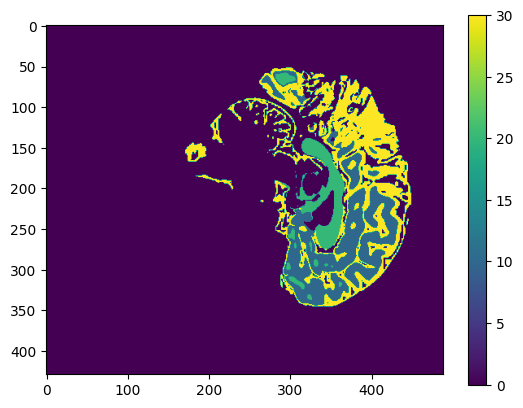

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
613


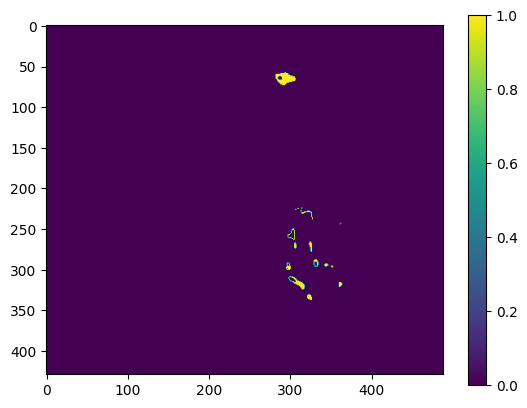

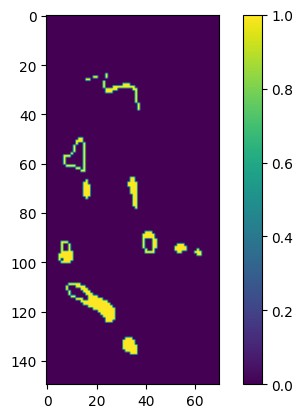

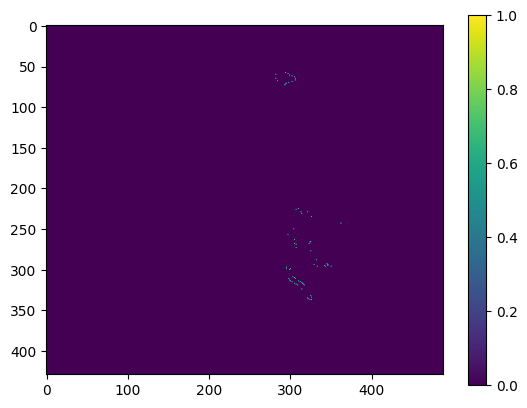

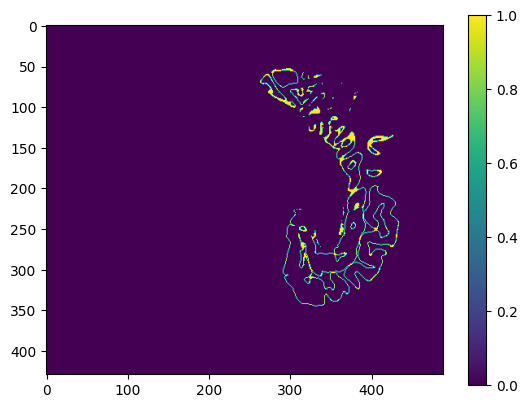

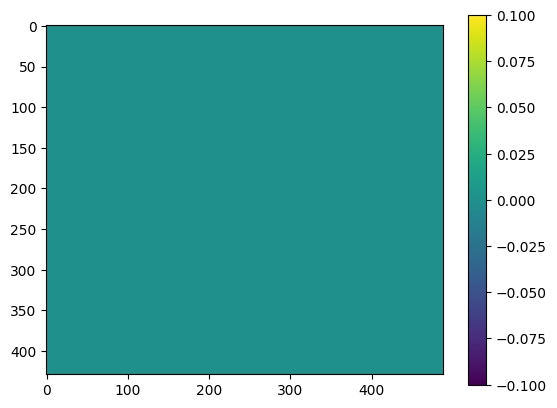

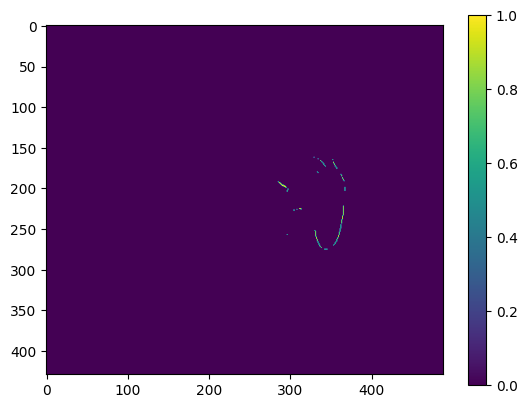

In [62]:
def make_boundary_mesh():
    "make a mesh of the surface boundary between two tissues (in the end I used all tissues of csf and all tissues of wm instead of just 1)"
    "changed it to specifically GM/CSF border and GM/WM border"

    matrix = brainmap
    # Assume `matrix` is your 3D numpy array
    mask_GM = (matrix == 16)
    mask_WM = (matrix == 34) + (matrix == 33) + (matrix == 32) + (matrix == 31) + (matrix == 30) + (matrix == 29) + (matrix == 28) + (matrix == 27) + (matrix == 26) + (matrix == 49)
    mask_CSF = (matrix == 17) + (matrix == 18) + (matrix == 19) + (matrix == 20) + (matrix == 21) + (matrix == 22) + (matrix == 23) + (matrix == 24) + (matrix == 25) + (matrix == 10)
    mask_WMsingle = (matrix == 34)
    mask_CSFsingle = (matrix == 17)

    masks = mask_GM*10 + mask_WM*20 + mask_CSF*30

    plt.imshow(masks[160])
    plt.colorbar()
    plt.show()
    # Find boundary: voxels adjacent to both masks
    boundaryGW = np.zeros_like(matrix, dtype=bool)
    boundaryGC = np.zeros_like(matrix, dtype=bool)
    # Dilate mask16 and intersect with mask34
    from scipy.ndimage import binary_dilation

    boundaryGW = binary_dilation(mask_GM) & mask_WM
    boundaryGC = binary_dilation(mask_GM) & mask_CSF
    boundaryWC = binary_dilation(mask_WM) & mask_CSF #should be (almost) empty
    boundaryGWsingle = binary_dilation(mask_GM) & mask_WMsingle
    boundaryGCsingle = binary_dilation(mask_GM) & mask_CSFsingle

    print(boundaryGW[160])
    print(np.sum(boundaryGW[160]))
    plt.imshow(boundaryGW[160])
    plt.colorbar()
    plt.show()

    plt.imshow(((boundaryGW[160]==1)*1)[200:350,290:360])
    plt.colorbar()
    plt.show()

    plt.imshow(boundaryGWsingle[160])
    plt.colorbar()
    plt.show()

    plt.imshow(boundaryGC[160])
    plt.colorbar()
    plt.show()

    plt.imshow(boundaryGCsingle[160])
    plt.colorbar()
    plt.show()

    plt.imshow(boundaryWC[160])
    plt.colorbar()
    plt.show()

    # Extract mesh using marching cubes
    boundaryGW_dilated = binary_dilation(boundaryGW, iterations=1)
    boundaryGC_dilated = binary_dilation(boundaryGC, iterations=1)
    vertsGW, facesGW, normalsGW, valuesGW = measure.marching_cubes(boundaryGW_dilated.astype(float), level=0.5)
    vertsGC, facesGC, normalsGC, valuesGC = measure.marching_cubes(boundaryGC_dilated.astype(float), level=0.5)
    # vertsWC, facesWC, normalsWC, valuesWC = measure.marching_cubes(boundaryWC.astype(float), level=0.5)

    # meshio.write(rf"tissue_meshes\test\boundary_gm_wm.stl", meshio.Mesh(points=vertsGW, cells=[("triangle", facesGW)]))
    # meshio.write(rf"tissue_meshes\test\boundary_gm_csf.stl", meshio.Mesh(points=vertsGC, cells=[("triangle", facesGC)]))
    # meshio.write(rf"tissue_meshes\test\boundary_wm_csf.stl", meshio.Mesh(points=vertsWC, cells=[("triangle", facesWC)]))

    #alternative with trimesh
    meshGW = trimesh.Trimesh(vertices=vertsGW, faces=facesGW)
    meshGW.export(rf"tissue_meshes\test\boundary_gm_wm.stl")
    meshGC = trimesh.Trimesh(vertices=vertsGC, faces=facesGC)
    meshGC.export(rf"tissue_meshes\test\boundary_gm_csf.stl")
make_boundary_mesh()

In [ ]:
def create_layers(subject):

    # Input STL files
    file1 = rf"tissue_meshes\subjects\s{subject}\boundary_gm_csf.stl"  # Replace with your first STL file
    file2 = rf"tissue_meshes\subjects\s{subject}\boundary_gm_wm.stl"  # Replace with your second STL file
    
    # Normalized depths for intermediate layers
    depths = [0.06, 0.4, 0.55, 0.65, 0.85]

    # Load meshes using trimesh
    mesh1 = trimesh.load_mesh(file1)
    mesh2 = trimesh.load_mesh(file2)
    print('loaded')
    # Convert trimesh meshes to Open3D point clouds for ICP
    pcd1 = o3d.geometry.PointCloud()
    pcd1.points = o3d.utility.Vector3dVector(mesh1.vertices)

    pcd2 = o3d.geometry.PointCloud()
    pcd2.points = o3d.utility.Vector3dVector(mesh2.vertices)

    # Initial alignment (identity)
    trans_init = np.eye(4)

    # ICP registration
    threshold = 5.0  # Adjust based on scale of your meshes
    reg_p2p = o3d.pipelines.registration.registration_icp(
        pcd2, pcd1, threshold, trans_init,
        o3d.pipelines.registration.TransformationEstimationPointToPoint()
    )

    # Apply ICP transformation to mesh2
    mesh2.apply_transform(reg_p2p.transformation)

    # Extract aligned vertices
    vertices1 = mesh1.vertices
    vertices2 = mesh2.vertices
    faces1 = mesh1.faces  # We'll reuse faces from mesh1 for output layers

    # Build KDTree for mesh2 to find nearest points for mesh1 vertices
    tree2 = cKDTree(vertices2)
    _, idx = tree2.query(vertices1)
    matched_vertices2 = vertices2[idx]

    # Interpolation function
    def interpolate_vertices(v1, v2, depth):
        return (1 - depth) * v1 + depth * v2

    # Generate and save intermediate layers
    layers = ['1','23','4','5','6']
    for i, d in enumerate(depths):
        print(layers[i])
        interpolated_vertices = interpolate_vertices(vertices1, matched_vertices2, d)
        new_mesh = trimesh.Trimesh(vertices=interpolated_vertices, faces=faces1)
        output_file = f"tissue_meshes\\subjects\\s{subject}\\layers\\layer_{layers[i]}_depth_{d:.2f}.stl"
        new_mesh.export(output_file)
        print(f"Saved interpolated layer {layers[i]} at depth {d} -> {output_file}")

for subject in [3]:
    print(subject)
    create_layers(subject)


3
loaded
0
1
Saved interpolated layer 0 at depth 0.06 -> tissue_meshes\subjects\s3\layers\layer_1_depth_0.06.stl
1
23
Saved interpolated layer 1 at depth 0.4 -> tissue_meshes\subjects\s3\layers\layer_23_depth_0.40.stl
2
4
Saved interpolated layer 2 at depth 0.55 -> tissue_meshes\subjects\s3\layers\layer_4_depth_0.55.stl
3
5
Saved interpolated layer 3 at depth 0.65 -> tissue_meshes\subjects\s3\layers\layer_5_depth_0.65.stl
4
6
Saved interpolated layer 4 at depth 0.85 -> tissue_meshes\subjects\s3\layers\layer_6_depth_0.85.stl


In [ ]:
def create_boundaries(subject):

    # Input STL files
    file1 = rf"tissue_meshes\subjects\s{subject}\boundary_gm_csf.stl"  # Replace with your first STL file
    file2 = rf"tissue_meshes\subjects\s{subject}\boundary_gm_wm.stl"  # Replace with your second STL file
    
    # Normalized depths for intermediate layers
    depths = [0.08, 0.51, 0.59, 0.81]

    # Load meshes using trimesh
    mesh1 = trimesh.load_mesh(file1)
    mesh2 = trimesh.load_mesh(file2)
    print('loaded')
    # Convert trimesh meshes to Open3D point clouds for ICP
    pcd1 = o3d.geometry.PointCloud()
    pcd1.points = o3d.utility.Vector3dVector(mesh1.vertices)

    pcd2 = o3d.geometry.PointCloud()
    pcd2.points = o3d.utility.Vector3dVector(mesh2.vertices)

    # Initial alignment (identity)
    trans_init = np.eye(4)

    # ICP registration
    threshold = 5.0  # Adjust based on scale of your meshes
    reg_p2p = o3d.pipelines.registration.registration_icp(
        pcd2, pcd1, threshold, trans_init,
        o3d.pipelines.registration.TransformationEstimationPointToPoint()
    )

    # Apply ICP transformation to mesh2
    mesh2.apply_transform(reg_p2p.transformation)

    # Extract aligned vertices
    vertices1 = mesh1.vertices
    vertices2 = mesh2.vertices
    faces1 = mesh1.faces  # We'll reuse faces from mesh1 for output layers

    # Build KDTree for mesh2 to find nearest points for mesh1 vertices
    tree2 = cKDTree(vertices2)
    _, idx = tree2.query(vertices1)
    matched_vertices2 = vertices2[idx]

    # Interpolation function
    def interpolate_vertices(v1, v2, depth):
        return (1 - depth) * v1 + depth * v2

    # Generate and save intermediate layers
    layers = ['1','23','4','5','6']
    for i, d in enumerate(depths):
        print(i)
        interpolated_vertices = interpolate_vertices(vertices1, matched_vertices2, d)
        new_mesh = trimesh.Trimesh(vertices=interpolated_vertices, faces=faces1)
        output_file = f"tissue_meshes\\subjects\\s{subject}\\layers\\boundary_{layers[i]}_depth_{d:.2f}.stl"
        new_mesh.export(output_file)
        print(f"Saved interpolated layer {layers[i]} at depth {d} -> {output_file}")

for subject in [3]:
    print(subject)
    create_boundaries(subject)


3
loaded
0
1
Saved interpolated layer 0 at depth 0.08 -> tissue_meshes\subjects\s3\layers\boundary_1_depth_0.08.stl
1
23
Saved interpolated layer 1 at depth 0.51 -> tissue_meshes\subjects\s3\layers\boundary_23_depth_0.51.stl
2
4
Saved interpolated layer 2 at depth 0.59 -> tissue_meshes\subjects\s3\layers\boundary_4_depth_0.59.stl
3
5
Saved interpolated layer 3 at depth 0.81 -> tissue_meshes\subjects\s3\layers\boundary_5_depth_0.81.stl


In [ ]:
for meshname in ['layer_1_depth_0.06', 'layer_23_depth_0.40', 'layer_4_depth_0.55', 'layer_5_depth_0.65', 'layer_6_depth_0.85']:
    print(meshname)
    subject = 3
    mesh = trimesh.load_mesh(rf"tissue_meshes\subjects\s{subject}\layers\{meshname}.stl")  # Replace with your STL file

    # Point in space
    point = np.array([159, 87, 323])  # Replace with your point coordinates

    # Compute closest point on the mesh and corresponding face index
    closest_point, distance, triangle_id = trimesh.proximity.closest_point(mesh, [point])

    print(f"Closest face index: {triangle_id[0]}")
    print(f"Closest point on mesh: {closest_point[0]}")
    print(f"Vertices of that face: {mesh.vertices[mesh.faces[triangle_id[0]]]}")

layer_1_depth_0.06
Closest face index: 1896412
Closest point on mesh: [159.15343935  87.15343935 322.86393489]
Vertices of that face: [[159.43783569  86.99538422 323.00640869]
 [158.96783447  87.46538544 323.00640869]
 [158.96783447  86.99539948 322.47640991]]
layer_23_depth_0.40
Closest face index: 1896412
Closest point on mesh: [159.01671826  87.01671868 322.99283727]
Vertices of that face: [[159.08558655  86.96923828 323.04275513]
 [158.7855835   87.2692337  323.04275513]
 [158.78559875  86.96931458 322.34274292]]
layer_4_depth_0.55
Closest face index: 1896280
Closest point on mesh: [158.91987844  86.95770753 323.02325451]
Vertices of that face: [[158.93019104  86.95770264 323.05877686]
 [158.7052002   86.95780945 322.28378296]
 [158.70518494  86.73270416 323.05877686]]
layer_5_depth_0.65
Closest face index: 1896281
Closest point on mesh: [158.87857049  86.95001221 323.1214401 ]
Vertices of that face: [[159.00158691  86.95001221 323.2444458 ]
 [158.82658386  86.95001221 323.06945801

In [ ]:
for meshname in ['layer_1_depth_0.06', 'layer_23_depth_0.40', 'layer_4_depth_0.55', 'layer_5_depth_0.65', 'layer_6_depth_0.85']:
    print("\n\n\n",meshname)
    subject = 3
    mesh = trimesh.load_mesh(rf"tissue_meshes\subjects\s{subject}\layers\{meshname}.stl")  # Replace with your STL file

    # Point in space
    point = np.array([159, 87, 323])  # Replace with your point coordinates

    # Compute centroids of all faces
    face_vertices = mesh.vertices[mesh.faces]  # Shape: (num_faces, 3, 3)
    centroids = face_vertices.mean(axis=1)     # Shape: (num_faces, 3)

    # Compute distances from point to each centroid
    distances = np.linalg.norm(centroids - point, axis=1)

    # Get indices of 10 closest faces
    closest_indices = np.argsort(distances)[:10]

    # For each face, compute centroid and normal
    results = []
    for idx in closest_indices:
        centroid = centroids[idx]
        normal = mesh.face_normals[idx]
        results.append({
            "face_index": idx,
            "centroid": centroid,
            "normal": normal
        })

    # Print results
    for r in results:
        print(f"Face {r['face_index']}:\nCentroid=np.array([{r['centroid'][0]}, {r['centroid'][1]}, {r['centroid'][2]}])\nNormal=np.array([{r['normal'][0]}, {r['normal'][1]}, {r['normal'][2]}])")




 layer_1_depth_0.06
Face 1896412:
Centroid=np.array([159.12450154622397, 87.15205637613933, 322.8297424316406])
Normal=np.array([-0.5990755309482548, -0.5990755309482548, 0.5312410153952093])
Face 1896280:
Centroid=np.array([159.12450154622397, 86.8387222290039, 322.8297424316406])
Normal=np.array([-0.5990645527234862, 0.5990645527234862, 0.5312657746744269])
Face 1873842:
Centroid=np.array([158.81116739908853, 86.8387222290039, 322.8297424316406])
Normal=np.array([0.5990645527234862, 0.5990645527234862, 0.5312657746744269])
Face 1896416:
Centroid=np.array([159.43783569335938, 87.1520512898763, 323.16307576497394])
Normal=np.array([-0.5773502691896257, -0.5773502691896257, 0.5773502691896257])
Face 1896281:
Centroid=np.array([159.43783569335938, 86.83871714274089, 323.16307576497394])
Normal=np.array([-0.5773502691896257, 0.5773502691896257, 0.5773502691896257])
Face 1873980:
Centroid=np.array([158.8011678059896, 87.4753901163737, 322.8297424316406])
Normal=np.array([-0.599075530948

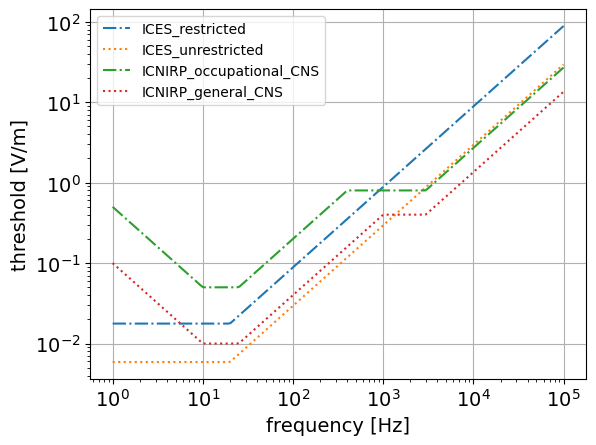

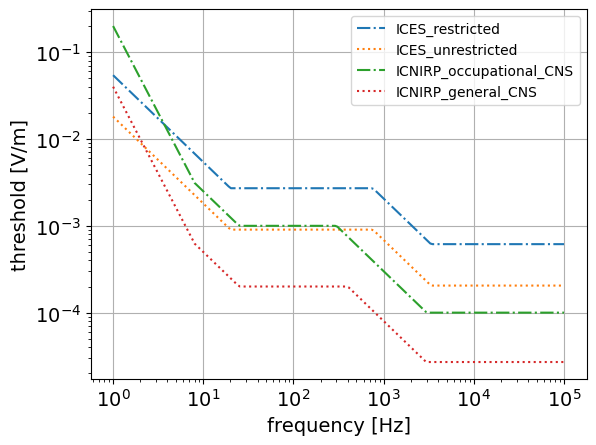

In [3]:
def plot_guidelines():
    freq_array = np.logspace(0,5,200) #np.logspace(2,5,200) #10 points is used so safety factors can be compared with simulation results

    #ICES
    E0_unres = 5.89*1e-3
    E0_res = 1.77*1e-2
    DRL_ICES_unres = np.array([E0_unres if freq < 20 else E0_unres*freq/20 for freq in freq_array])
    DRL_ICES_res = np.array([E0_res if freq < 20 else E0_res*freq/20 for freq in freq_array])
    #ICNIRP
    BS_ICNIRP_occ_CNS = np.array([0.5/freq if freq < 10 else 0.05 if freq <25 else 2*1e-3*freq if freq < 400 else 0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
    #BS_ICNIRP_occ_PNS = np.array([0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
    BS_ICNIRP_gen_CNS = np.array([0.1/freq if freq < 10 else 0.01 if freq <25 else 4*1e-4*freq if freq < 1000 else 0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])
    #BS_ICNIRP_gen_PNS = np.array([0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])

    #guidelines plotting
    plt.loglog(freq_array,DRL_ICES_res,'-.',label='ICES_restricted') #occupational
    plt.loglog(freq_array,DRL_ICES_unres,':',label='ICES_unrestricted') #general
    plt.loglog(freq_array,BS_ICNIRP_occ_CNS,'-.',label='ICNIRP_occupational_CNS') #occupational CNS
    #plt.plot(freq_array,BS_ICNIRP_occ_PNS,'-.',label='ICNIRP_occupational_PNS') #occupational PNS   
    plt.loglog(freq_array,BS_ICNIRP_gen_CNS,':',label='ICNIRP_general_CNS') #occupational CNS
    #plt.plot(freq_array,BS_ICNIRP_gen_PNS,':',label='ICNIRP_general_PNS') #occupational PNS 
    plt.legend()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel('frequency [Hz]',fontsize=14)
    plt.ylabel('threshold [V/m]',fontsize=14)
    plt.grid()


def plot_guidelines_ext():
    freq_array = np.logspace(0,5,200) #np.logspace(2,5,200) #10 points is used so safety factors can be compared with simulation results

    #ICES
    DRL_ICES_unres = np.array([118 if freq < 0.153 else 18.1/freq if freq < 20 else 0.904 if freq < 751 else 687/freq if freq < 3.35*1e3 else 0.205 for freq in freq_array])*1e-3 #mT -> T
    DRL_ICES_res = np.array([353 if freq < 0.153 else 54.3/freq if freq < 20 else 2.71 if freq < 751 else 2060/freq if freq < 3.35*1e3 else 0.615 for freq in freq_array])*1e-3 #mT -> T
    #ICNIRP
    BS_ICNIRP_occ_CNS = np.array([0.2/freq**2 if freq < 8 else 2.5*1e-2/freq if freq < 25 else 1*1e-3 if freq < 300 else 0.3/freq if freq < 3*1e3 else 1e-4 for freq in freq_array])
    BS_ICNIRP_gen_CNS = np.array([4*1e-2/freq**2 if freq < 8 else 5*1e-3/freq if freq < 25 else 2*1e-4 if freq < 400 else 8*1e-2/freq if freq < 3*1e3 else 2.7*1e-5 for freq in freq_array])

    #guidelines plotting
    plt.loglog(freq_array,DRL_ICES_res,'-.',label='ICES_restricted') #occupational
    plt.loglog(freq_array,DRL_ICES_unres,':',label='ICES_unrestricted') #general
    plt.loglog(freq_array,BS_ICNIRP_occ_CNS,'-.',label='ICNIRP_occupational_CNS') #occupational CNS
    #plt.plot(freq_array,BS_ICNIRP_occ_PNS,'-.',label='ICNIRP_occupational_PNS') #occupational PNS   
    plt.loglog(freq_array,BS_ICNIRP_gen_CNS,':',label='ICNIRP_general_CNS') #occupational CNS
    #plt.plot(freq_array,BS_ICNIRP_gen_PNS,':',label='ICNIRP_general_PNS') #occupational PNS 
    plt.legend()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel('frequency [Hz]',fontsize=14)
    plt.ylabel('threshold [V/m]',fontsize=14)
    plt.grid()


def give_guidelines(CNS=0):
    freq_array = np.logspace(2,5,10) #np.logspace(2,5,200) #10 points is used so safety factors can be compared with simulation results

    #ICES
    E0_unres = 5.89*1e-3
    E0_res = 1.77*1e-2
    DRL_ICES_unres = np.array([E0_unres if freq < 20 else E0_unres*freq/20 for freq in freq_array])
    DRL_ICES_res = np.array([E0_res if freq < 20 else E0_res*freq/20 for freq in freq_array])
    #ICNIRP
    BS_ICNIRP_occ_CNS = np.array([0.5/freq if freq < 10 else 0.05 if freq <25 else 2*1e-3*freq if freq < 400 else 0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
    #BS_ICNIRP_occ_PNS = np.array([0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
    BS_ICNIRP_gen_CNS = np.array([0.1/freq if freq < 10 else 0.01 if freq <25 else 4*1e-4*freq if freq < 1000 else 0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])
    #BS_ICNIRP_gen_PNS = np.array([0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])

    if CNS:
        return([DRL_ICES_unres,DRL_ICES_res,BS_ICNIRP_occ_CNS,BS_ICNIRP_gen_CNS])

    return np.max([DRL_ICES_unres,DRL_ICES_res,BS_ICNIRP_occ_CNS,BS_ICNIRP_gen_CNS],axis=0)

def safety_factor(guideline,freq):
    if guideline == 'DRL_ICES_unres':
        return 9
    elif guideline == 'DRL_ICES_res':
        return 3
    elif guideline == 'BS_ICNIRP_gen_CNS':
        return 5 if freq < 1e3 else 10
    elif guideline == 'BS_ICNIRP_occ_CNS':
        return 1 if freq < 400 else 5


def give_guidelines_ext(CNS=0):
    freq_array = np.logspace(2,5,10) #np.logspace(2,5,200) #10 points is used so safety factors can be compared with simulation results

    #ICES
    DRL_ICES_unres = np.array([118 if freq < 0.153 else 18.1/freq if freq < 20 else 0.904 if freq < 751 else 687/freq if freq < 3.35*1e3 else 0.205 for freq in freq_array])*1e-3 #mT -> T
    DRL_ICES_res = np.array([353 if freq < 0.153 else 54.3/freq if freq < 20 else 2.71 if freq < 751 else 2060/freq if freq < 3.35*1e3 else 0.615 for freq in freq_array])*1e-3 #mT -> T
    #ICNIRP
    BS_ICNIRP_occ_CNS = np.array([0.2/freq**2 if freq < 8 else 2.5*1e-2/freq if freq < 25 else 1*1e-3 if freq < 300 else 0.3/freq if freq < 3*1e3 else 1e-4 for freq in freq_array])
    BS_ICNIRP_gen_CNS = np.array([4*1e-2/freq**2 if freq < 8 else 5*1e-3/freq if freq < 25 else 2*1e-4 if freq < 400 else 8*1e-2/freq if freq < 3*1e3 else 2.7*1e-5 for freq in freq_array])

    if CNS:
        return([DRL_ICES_unres,DRL_ICES_res,BS_ICNIRP_occ_CNS,BS_ICNIRP_gen_CNS])

    return np.max([DRL_ICES_unres,DRL_ICES_res,BS_ICNIRP_occ_CNS,BS_ICNIRP_gen_CNS],axis=0)

%matplotlib inline
plot_guidelines()
plt.show()
plot_guidelines_ext()
plt.show()


safety factors for ([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],[3, 7, 12, 17, 18, 19, 20, 21, 22, 23, 24],['lateral', 'superior', 'anterior', 'medial', 'inferior', 'posterior']): min_thresh/max_guidelines 
= [15.28089438 11.38815385  9.48492094 12.61760082  9.98468767  7.15674659
  5.67937301  4.24564855  3.47668726  2.83640729]


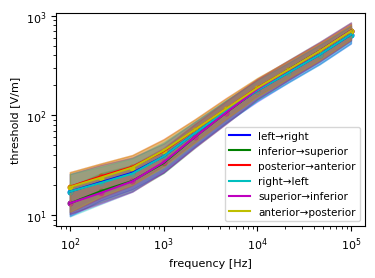

(6, 25, 11, 10, 10)
(2750, 10)
slat: [ 14.52687146  16.29365658  18.49526751  23.42340546  32.18546486
  48.70196751  70.96220028  98.67700468 144.56177475 215.23804634]
ssup: [ 10.80787335  11.58384163  12.84546694  16.05819216  24.49450858
  40.66808951  63.68475134  95.92682675 140.68614904 210.54307787]
sant: [ 12.26121112  15.02860309  17.21080004  21.05983969  29.29713908
  41.88487175  57.85840271  85.02781728 127.76812889 192.87429491]
['lateral', 'lateral', 'lateral', 'lateral', 'lateral', 'lateral', 'lateral', 'lateral', 'lateral', 'lateral']


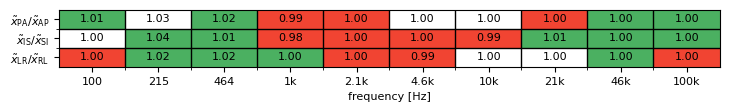

In [ ]:

"""direction variations"""

cells = [cel for cel in range(1,26)]
subjects = [3,7,12,17,18,19,20,21,22,23,24]
directions = ['lateral', 'superior', 'anterior'] + ['medial', 'inferior', 'posterior']
#cells = [1,2,3,4,5,6,7,8,9,10,11,15,16,20,21,22,23,24,25] #cells[0:5] + cells[5:10] + cells[10:11] + cells[15:16] + cells[20:25] #[1,2,3,4,5], [6,7,8,9,10], [11,12,13,14,15], [16,17,18,19,20], [21,22,23,24,25]
len_loc = 10
len_freq = 10
direction_map = {'lateral' : 'left → right', 'anterior' : 'posterior → anterior', 'superior' : 'inferior → superior', 'medial' : 'right → left', 'posterior' : 'anterior → posterior', 'inferior' : 'superior → inferior'}
direction_map = {'lateral' : 'left→right', 'anterior' : 'posterior→anterior', 'superior' : 'inferior→superior', 'medial' : 'right→left', 'posterior' : 'anterior→posterior', 'inferior' : 'superior→inferior'}
#direction_map = {'lateral': 'lateral/medial', 'anterior':'posterior/anterior', 'superior':'inferior/superior'}

colors = ['b','g','r','c','m','y','tab:orange','tab:pink','tab:brown','k']
#colors = ['b','y','r','g','c']
type1, type2, type3, type4, type5 = "L1 NGC-DA", "L2/3 PC", "L4 LBC", "L5 TTPC", "L6 TPC"
cell_names = [type1]*5 + [type2]*5 + [type3]*5 + [type4]*5 + [type5]*5
i = 0

opposite_direction = {'lateral':'medial', 'superior':'inferior', 'anterior':'posterior'} #opposite polarity

all_freqs, all_threshs = np.empty((len(directions),len(cells),len(subjects),len_loc,len_freq)), np.empty((len(directions),len(cells),len(subjects),len_loc,len_freq)) #directions, locations*subjects, frequencies
#all_freqs, all_threshs = np.empty((len(cells),len(directions),len(subjects),len_loc,len_freq)), np.empty((len(cells),len(directions),len(subjects),len_loc,len_freq)) #directions, locations*subjects, frequencies


for id,direction in enumerate(directions): # ic,cell in enumerate(cells) #id,direction in enumerate(directions)
    freqs, threshs = np.empty((len(cells),len(subjects),len_loc,len_freq)), np.empty((len(cells),len(subjects),len_loc,len_freq))
    #freqs, threshs = np.empty((len(directions),len(subjects),len_loc,len_freq)), np.empty((len(directions),len(subjects),len_loc,len_freq))
    for ic,cell in enumerate(cells): # id,direction in enumerate(directions) #ic,cell in enumerate(cells)
        for isub, subject in enumerate(subjects): #isub, subject in enumerate(subjects)
            with open(rf"results\FEM\interpol_linear_logspace_(10, 2, 5)_cell_nr_{cell}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                pkl = pickle.load(f)
            #with open(rf"results\FEM\interpol_linear_logspace_(10, 2, 5)_cell_nr_{cell}_dt_fact_100_subject_{subject}_direction_{opposite_direction[direction]}.pkl",'rb') as f: #opposite polarity
                #pkl_op = pickle.load(f) #opposite polarity
            hs300 = pkl['hotspot_300']
            hs100k = pkl['hotspot_100k']
            #hs300_op = pkl_op['hotspot_300'] #opposite polarity
            #hs100k_op = pkl_op['hotspot_100k'] #opposite polarity

            if sum(hs300[0]['location']==hs100k[0]['location']) == 3:
                #for iloc,val300 in enumerate(hs300.values()): #10 locations
                for (iloc,val300), (iloc_op,val300_op) in zip(enumerate(hs300.values()), enumerate(hs300_op.values())): #opposite polarity
                    freq = val300['freq']
                    thresh = val300['thresh']/np.sqrt(2) #peak->RMS
                    #thresh = (val300['thresh']/np.sqrt(2) + val300_op['thresh']/np.sqrt(2))/2 #opposite polarity
                    freqs[ic,isub,iloc] = freq #ic,isub,iloc
                    threshs[ic,isub,iloc] = thresh
            else:
                for iloc, (val300, val100k) in enumerate(zip(hs300.values(),hs100k.values())): #10 locations
                #for (iloc, (val300, val100k)), (iloc_op, (val300_op, val100k_op)) in zip(enumerate(zip(hs300.values(), hs100k.values())),enumerate(zip(hs300_op.values(), hs100k_op.values()))): #opposite polarity
                    freq = val300['freq']
                    thresh = np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2) #peak->RMS
                    #thresh = (np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2)+np.min((val300_op['thresh'], val100k_op['thresh']),axis=0)/np.sqrt(2))/2 #opposite polarity
                    freqs[ic,isub,iloc] = freq
                    threshs[ic,isub,iloc] = thresh
    all_freqs[id] = freqs #id
    all_threshs[id] = threshs
    threshs_flat = threshs.reshape(-1,10)
    q0 = np.quantile(threshs_flat,0/4,axis=0)
    q25 = np.quantile(threshs_flat,1/4,axis=0)
    q50 = np.quantile(threshs_flat,2/4,axis=0)
    q75 = np.quantile(threshs_flat,3/4,axis=0)
    q100 = np.quantile(threshs_flat,4/4,axis=0)

    plt.scatter(freq,q50,c = colors[i],s=10)
    plt.plot(freq,q50,label=f'{direction_map[direction]}',color = colors[i]) #,color='r'
    plt.fill_between(freq,q25,q75,alpha=0.3,color = colors[i]) #,label=f'25-75 ({direction})'
    #plt.fill_between(freq,q0,q100,alpha=0.15,color = colors[i]) #,label=f'25-75 ({direction})'
    # plt.plot(freq,q0,color = colors[i])
    # plt.plot(freq,q100,color = colors[i])
    i+=1
all_threshs_flat = all_threshs.reshape(-1,10)
min_thresh = np.min(all_threshs_flat,axis=0)
max_guidelines = give_guidelines()
print(f'\nsafety factors for ({cells},{subjects},{directions}): min_thresh/max_guidelines \n= {min_thresh/max_guidelines}')
guidelines = give_guidelines(CNS=1)
for guideline, name, fr in zip(guidelines, ['DRL_ICES_unres','DRL_ICES_res','BS_ICNIRP_occ_CNS','BS_ICNIRP_gen_CNS'], freq):
    continue
    #print(f' min_thresh/{name}: \n= {min_thresh/guideline}')
    print(name)
    sf = [safety_factor(name,fr) for fr in freq]
    print((min_thresh/guideline))
    print((min_thresh/guideline/sf))
    #print(np.sum((min_thresh/guideline/sf)<1))

#plot_guidelines()
plt.grid()
plt.xlabel('frequency [Hz]',fontsize = 8)
plt.ylabel('threshold [V/m]',fontsize = 8)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.xscale('log')
plt.yscale('log')
plt.grid() 
plt.legend(loc='lower right',fontsize=7.5)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()

"""final plot combining all plots"""

print(all_threshs.shape)
lat = (all_threshs[0]).reshape(-1,10)
sup = (all_threshs[1]).reshape(-1,10)
ant = (all_threshs[2]).reshape(-1,10)
med = (all_threshs[3]).reshape(-1,10)
inf = (all_threshs[4]).reshape(-1,10)
pos = (all_threshs[5]).reshape(-1,10)

latmed = (lat+med)/2 #opposite polarity
supinf = (sup+inf)/2 #opposite polarity
antpos = (ant+pos)/2 #opposite polarity

print(lat.shape)

"violin plots"
violin = 0
if violin:
    for fr in range(10):
        violins = []
        for i,e in enumerate([lat,sup,ant,med,inf,pos]):
            violin = e[:,fr]
            violins += [violin]
            plt.scatter(i+1,np.median(violin))
            print(f"direction: {directions[i]} = {direction_map[directions[i]]}, mini: {np.min(violin)}, maxi: {np.max(violin)}, maxi/mini = {np.max(violin)/np.min(violin)}")
        maxmin = [np.max(e)/np.min(e) for e in violins]
        medians =  [np.median(e) for e in violins]
        mins =  [np.min(e) for e in violins]
        sorted_medians = np.array(directions)[np.argsort(medians)]
        sorted_mins = np.array(directions)[np.argsort(mins)]
        print(f"sorted medians: {sorted_medians}")
        print(f"sorted mins: {sorted_mins}")
        print(f"median_{sorted_medians[-1]}/median_{sorted_medians[0]} = {medians[np.argsort(medians)[-1]]} / {medians[np.argsort(medians)[0]]} = {medians[np.argsort(medians)[-1]] / medians[np.argsort(medians)[0]]}")
        print(f"sorted maxi/mini: {np.array([direction_map[dir] for dir in directions])[np.flip(np.argsort(maxmin))]}")
        plt.violinplot(violins)
        plt.yscale('log')
        plt.xticks([1,2,3,4,5,6],['lateral','superior','anterior','medial','inferior','posterior'])
        plt.grid()
        plt.title(f'frequency = {np.round(freq[fr])} Hz')
        plt.show()


"difference violin plots (only for the original 3 directions)"
diff_violin = 0
if diff_violin:
    for fr in range(10):
        violins = []
        for i,(e,f) in enumerate(zip([lat,sup,ant],[sup,ant,lat])):
            violin1 = e[:,fr]
            violin2 = f[:,fr]
            violindiff = violin1-violin2
            violins += [violindiff]
            plt.scatter(i+1,np.median(violindiff))
            print('symmetry:')
            print(f'mean:{np.mean(violindiff)}, median:{np.median(violindiff)}, relative error: {(np.mean(violindiff)-np.median(violindiff))/np.median(violindiff)}')
            print(f'skewness: {skew(violindiff)}')
        plt.violinplot(violins)
        plt.xticks([1,2,3],['lateral-superior','superior-anterior','anterior-lateral'])
        plt.grid()
        plt.title(f'frequency = {np.round(freq[fr])} Hz')
        plt.show()



slat = np.std(lat,axis=0)
ssup = np.std(sup,axis=0)
sant = np.std(ant,axis=0)
#ANOVA = f_oneway(lat,sup,ant,axis=0)
#print(ANOVA)
print(f'slat: {slat}')
print(f'ssup: {ssup}')
print(f'sant: {sant}')
print(['anterior' if (a > l and a > s) else 'lateral' if (l > a and l > s) else 'superior' if (s > a and s > l) else 0 for (a,l,s) in zip(sant,slat,ssup)])

p_values = np.empty((15,10))
bigger_thans = np.empty((15,10))
significances = np.empty((15,10))
medians = np.empty((15,10))
mins = np.empty((15,10))

p_values = np.empty((3,10)) #opposite polarity
bigger_thans = np.empty((3,10)) #opposite polarity
significances = np.empty((3,10)) #opposite polarity
medians = np.empty((3,10)) #opposite polarity
mins = np.empty((3,10)) #opposite polarity

#for one-sided t-test
p_values2 = np.empty((15,2,10))
bigger_thans2 = np.empty((15,2,10))
significances2 = np.empty((15,2,10))

dir_dict = {str(ant): 'PA', str(sup): 'IS', str(lat): 'LR', str(pos): 'AP', str(inf): 'SI', str(med): 'RL'}
dir_dict = {**dir_dict,str(antpos): 'PA', str(supinf): 'IS', str(latmed): 'LM'} #opposite polarity

yticks = []
yticks2 = []

for i,(t1,t2) in enumerate(zip([ant,sup,lat], #opposite polarity bis
                               [pos,inf,med])): #opposite polarity bis
    tt = wilcoxon(t1,t2) #gives the same result as wilcoxon(t2,t1)
    pvalue = tt.pvalue
    p_values[i] = pvalue
    significant = np.where((pvalue > 0) & (pvalue <= 0.05), 1, 0)
    means = np.median(t1,axis=0) - np.median(t2,axis=0)
    median_ratio = np.median(t1,axis=0) / np.median(t2,axis=0)
    min_ratio = np.min(t1,axis=0) / np.min(t2,axis=0)
    bigger_than = np.where(means > 0, 1, -1)
    significant_bigger_than = significant * bigger_than
    bigger_thans[i] = bigger_than
    medians[i] = median_ratio
    mins[i] = min_ratio
    name1 = dir_dict[str(t1)]#.replace('-', r'\\text{-}')
    name2 = dir_dict[str(t2)]#.replace('-', r'\\text{-}')
    yticks += [fr'$\tilde{{x}}_{{\mathrm{{{name1}}}}} / \tilde{{x}}_{{\mathrm{{{name2}}}}}$']

#for one-sided t-test
for i,(t1,t2) in enumerate(zip([ant,ant,lat],[lat,sup,sup])):
    tt1 = wilcoxon(t1,t2,alternative='greater')
    tt2 = wilcoxon(t2,t1,alternative='greater')
    pvalue1 = tt1.pvalue
    pvalue2 = tt2.pvalue
    p_values2[i,0] = pvalue1
    p_values2[i,1] = pvalue2
    significant1 = np.where((pvalue1 > 0) & (pvalue1 <= 0.05), 1, 0)
    significant2 = np.where((pvalue2 > 0) & (pvalue2 <= 0.05), 1, 0)
    means1 = np.median(t1,axis=0) - np.median(t2,axis=0)
    means2 = np.median(t2,axis=0) - np.median(t1,axis=0)
    bigger_than1 = np.where(means > 0, 1, -1)
    bigger_than2 = np.where(means > 0, -1, 1)
    significant_bigger_than1 = significant1 * bigger_than1
    significant_bigger_than2 = significant2 * bigger_than2
    bigger_thans2[i,0] = bigger_than1
    bigger_thans2[i,1] = bigger_than2
    yticks2 += [f'{dir_dict[str(t1)]} > {dir_dict[str(t2)]}']
    yticks2 += [f'{dir_dict[str(t2)]} > {dir_dict[str(t1)]}']


redgreen = np.array([[0,1,2,3],[4,5,6,7]])
redgreen = np.array([[1,1,1,3],[5,5,5,7]])

for il,line in enumerate(significances):
    for iv,value in enumerate(line):
        irg = 0 if bigger_thans[il,iv] > 0 else 1
        jrg = 0 if p_values[il,iv] < 0.001 else 1 if p_values[il,iv] < 0.01 else 2 if p_values[il,iv] < 0.05 else 3
        significances[il,iv] = redgreen[irg,jrg]

#for one-sided t-test
for il,line in enumerate(significances):
    line1 = significances2[il,0]
    line2 = significances2[il,1]
    for iv,(value1,value2) in enumerate(zip(line1,line2)):
        irg = 0 if bigger_thans2[il,0,iv] > 0 else 1
        jrg = 0 if p_values2[il,0,iv] < 0.001 else 1 if p_values2[il,0,iv] < 0.01 else 2 if p_values2[il,0,iv] < 0.05 else 3
        significances2[il,0,iv] = redgreen[irg,jrg]
        irg = 0 if bigger_thans2[il,1,iv] > 0 else 1
        jrg = 0 if p_values2[il,1,iv] < 0.001 else 1 if p_values2[il,1,iv] < 0.01 else 2 if p_values2[il,1,iv] < 0.05 else 3
        significances2[il,1,iv] = redgreen[irg,jrg]

"plot two one-sided instead of two-sided"
# p_values = p_values2.reshape((-1,10))
# bigger_thans = bigger_thans2.reshape((-1,10))
# significances = significances2.reshape((-1,10))
# yticks = yticks2
        


from matplotlib.colors import ListedColormap

greens = plt.cm.Greens(np.linspace(0.4, 1, 4))  # lighter to darker green
reds = plt.cm.Reds(np.linspace(0.4, 1, 4))
greens[-1] = [1,1,1,0]
reds[-1] = [1,1,1,0] 
#alpha = 0.01 (significance level)
# greens[-2] = [1,1,1,0]
# reds[-2] = [1,1,1,0]
#alpha = 0.001 (significance level)
# greens[-3] = [1,1,1,0]
# reds[-3] = [1,1,1,0]
colors = [*greens, *reds]  # use hex colors here, if desired.
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(20,6))
plt.imshow(significances, vmin=0, vmax=len(cmap.colors), cmap=cmap)
#plt.imshow(np.ones((6,10)), vmin=0, vmax=len(cmap.colors), cmap=cmap)



def sci_text_clean(x, sig=2):
    """
    Format number for Matplotlib with superscript using MathText.
    Removes leading zeros in exponent (e.g., 10^9 instead of 10^09; 10^-9 instead of 10^-09).
    """
    s = f"{x:.{sig}e}"              # e.g., '1.23e-09'
    mantissa, exp = s.split("e")

    # Clean mantissa: remove trailing zeros and decimal point if needed
    mantissa = mantissa.rstrip("0").rstrip(".") or "0"

    # Parse exponent: capture sign and digits separately
    sign = "-" if exp.startswith("-") else ""
    digits = exp.lstrip("+-")                # remove any sign
    digits = digits.lstrip("0") or "0"       # strip leading zeros from digits only
    power = f"{sign}{digits}" if digits != "0" else "0"
    return fr"{mantissa}×10$^{{{power}}}$"



ax.set_aspect('auto')
for i in range(len(significances)):
    for j in range(len(significances[0])):
        #val = p_values[i, j] #before
        val = medians[i, j] 
        #val = mins[i, j]
        plt.text(
            #j, i, sci_text_clean(val, sig=2), #before
            j, i, f'{val:.2f}',
            ha="center", va="center",
            fontsize=8
        )
        #plt.text(j,i,sci_text_clean(p_values[i,j]),ha="center", va="center") #p-values are too long to show on a small square!


"plotting the colorbars"

plt.yticks([e for e in range(len(yticks))],yticks,fontsize=8)
plt.yticks([e+0.5 for e in range(len(yticks)-1)],minor=True,fontsize=8)
plt.xticks([e for e in range(10)],['100', '215', '464', '1k', '2.1k', '4.6k', '10k', '21k', '46k', '100k'],fontsize=8)
plt.xticks([e+0.49 for e in range(9)],minor=True,fontsize=8)
plt.xlabel('frequency [Hz]',fontsize=8)
plt.grid(which='minor', color='black', linestyle='-', linewidth=1)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.4,7.4*y_size/(x_size)*0.55)#fig.set_size_inches(7.4,7.4*y_size/(x_size)*1.4)
fig.tight_layout()
plt.show()

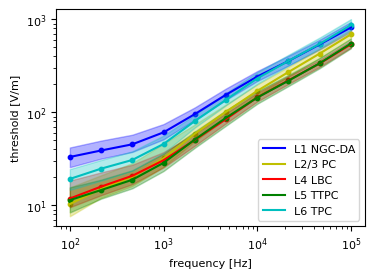

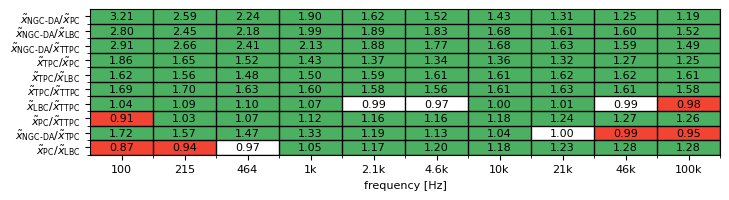

In [ ]:
"""cell variations"""

subjects = [3,7,12,17,18,19,20,21,22,23,24]
directions = ['lateral', 'superior', 'anterior'] #+ ['medial', 'inferior', 'posterior']
len_loc = 10
len_freq = 10
len_celltypes = 5
len_cellclones = 5
cells = [5*celltype + cellclone + 1 for celltype in range(len_celltypes) for cellclone in range(len_cellclones)]

colors = ['b','g','r','c','m','y','tab:orange','tab:pink','tab:brown','k']
colors = ['b','y','r','g','c']
type1, type2, type3, type4, type5 = "L1 NGC-DA", "L2/3 PC", "L4 LBC", "L5 TTPC", "L6 TPC"
celltypes = [type1, type2, type3, type4, type5]
cell_names = [type1]*5 + [type2]*5 + [type3]*5 + [type4]*5 + [type5]*5
i = 0

opposite_direction = {'lateral':'medial', 'superior':'inferior', 'anterior':'posterior'} #opposite polarity

all_freqs, all_threshs = np.empty((len_celltypes,len_cellclones,len(directions),len(subjects),len_loc,len_freq)), np.empty((len_celltypes,len_cellclones,len(directions),len(subjects),len_loc,len_freq))

with open('thresholds.csv','w') as th:

    for ict,celltype in enumerate(range(len_celltypes)):
        for icc,cellclone in enumerate(range(len_cellclones)):
            freqs, threshs = np.empty((len(directions),len(subjects),len_loc,len_freq)), np.empty((len(directions),len(subjects),len_loc,len_freq))
            for id,direction in enumerate(directions):
                for isub, subject in enumerate(subjects): 
                    with open(rf"results\FEM\interpol_linear_logspace_(10, 2, 5)_cell_nr_{5*celltype+cellclone+1}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                        pkl = pickle.load(f)
                    with open(rf"results\FEM\interpol_linear_logspace_(10, 2, 5)_cell_nr_{5*celltype+cellclone+1}_dt_fact_100_subject_{subject}_direction_{opposite_direction[direction]}.pkl",'rb') as f: #opposite polarity
                        pkl_op = pickle.load(f) #opposite polarity
                    hs300 = pkl['hotspot_300']
                    hs100k = pkl['hotspot_100k']
                    hs300_op = pkl_op['hotspot_300'] #opposite polarity
                    hs100k_op = pkl_op['hotspot_100k'] #opposite polarity

                    if sum(hs300[0]['location']==hs100k[0]['location']) == 3:
                        #for iloc,val300 in enumerate(hs300.values()): #10 locations
                        for (iloc,val300), (iloc_op,val300_op) in zip(enumerate(hs300.values()), enumerate(hs300_op.values())): #opposite polarity
                            freq = val300['freq']
                            thresh = val300['thresh']/np.sqrt(2) #peak->RMS
                            thresh = (val300['thresh']/np.sqrt(2) + val300_op['thresh']/np.sqrt(2))/2 #opposite polarity
                            freqs[id,isub,iloc] = freq #ic,isub,iloc
                            threshs[id,isub,iloc] = thresh
                    else:
                        #for iloc, (val300, val100k) in enumerate(zip(hs300.values(),hs100k.values())): #10 locations
                        for (iloc, (val300, val100k)), (iloc_op, (val300_op, val100k_op)) in zip(enumerate(zip(hs300.values(), hs100k.values())),enumerate(zip(hs300_op.values(), hs100k_op.values()))): #opposite polarity
                            freq = val300['freq']
                            thresh = np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2) #peak->RMS
                            thresh = (np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2)+np.min((val300_op['thresh'], val100k_op['thresh']),axis=0)/np.sqrt(2))/2 #opposite polarity
                            freqs[id,isub,iloc] = freq
                            threshs[id,isub,iloc] = thresh
                    for fr, thr in zip(freq, thresh):
                        th.write(f'{subject}, {5*celltype+cellclone+1}, {direction}, {fr},{thr}\n')
            all_freqs[ict,icc] = freqs #id
            all_threshs[ict,icc] = threshs
        
        threshs_flat = all_threshs[ict].reshape(-1,10)
        qmin = np.quantile(threshs_flat,1/4,axis=0)
        q50 = np.quantile(threshs_flat,2/4,axis=0)
        qmax = np.quantile(threshs_flat,3/4,axis=0)

        plt.scatter(freq,q50,c = colors[i],s=10)
        plt.plot(freq,q50,label=f'{celltypes[ict]}',color = colors[i]) #,color='r'
        plt.fill_between(freq,qmin,qmax,alpha=0.3,color = colors[i]) #,label=f'25-75 ({celltypes[ict]})'
        i+=1

#plot_guidelines()
plt.grid()
plt.xlabel('frequency [Hz]',fontsize = 8)
plt.ylabel('threshold [V/m]',fontsize = 8)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.xscale('log')
plt.yscale('log')
plt.grid() 
plt.legend(loc='lower right',fontsize=8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)
fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()


cell1 = (all_threshs[0]).reshape(-1,10)
cell23 = (all_threshs[1]).reshape(-1,10)
cell4 = (all_threshs[2]).reshape(-1,10)
cell5 = (all_threshs[3]).reshape(-1,10)
cell6 = (all_threshs[4]).reshape(-1,10)

"violin plots"
violin = 0
if violin:
    for fr in range(10):
        violins = []
        for i,e in enumerate([cell1,cell23,cell4,cell5,cell6]):
            violin = e[:,fr]
            violins += [violin]
            plt.scatter(i+1,np.median(violin))
            print(f"cell: {celltypes[i]}, mini: {np.min(violin)}, maxi: {np.max(violin)}, maxi/mini = {np.max(violin)/np.min(violin)}")
            #print('normality:')
            #print(f"shapiro: {shapiro(violin)}")
            #print(f"anderson: {anderson(x=violin,dist='norm')}")
        maxmin = [np.max(e)/np.min(e) for e in violins]
        medians =  [np.median(e) for e in violins]
        mins = [np.min(e) for e in violins]
        sorted_medians = np.array(celltypes)[np.argsort(medians)]
        sorted_mins = np.array(celltypes)[np.argsort(mins)]
        print(f"sorted medians: {sorted_medians}")
        print(f"sorted mins: {sorted_mins}")
        print(f"median_{sorted_medians[-1]}/median_{sorted_medians[0]} = {medians[np.argsort(medians)[-1]]} / {medians[np.argsort(medians)[0]]} = {medians[np.argsort(medians)[-1]] / medians[np.argsort(medians)[0]]}")
        print(f"sorted maxi/mini: {np.array(celltypes)[np.flip(np.argsort(maxmin))]}")
        plt.violinplot(violins)
        plt.yscale('log')
        plt.xticks([1,2,3,4,5],['NGC-DA','PC','LBC','TTPC','TPC'])
        plt.grid()
        plt.title(f'frequency = {np.round(freq[fr])} Hz')
        plt.show()

p_values = np.empty((10,10))
bigger_thans = np.empty((10,10))
significances = np.empty((10,10))
medians = np.empty((10,10))
mins = np.empty((10,10))

cell_dict = {str(cell1): 'NGC-DA', str(cell23): 'PC', str(cell4): 'LBC', str(cell5): 'TTPC', str(cell6): 'TPC'}

yticks = []
for i,(t1,t2) in enumerate(zip([cell1,cell1,cell1,cell6,cell6,cell6,cell4,cell23,cell1,cell23],[cell23,cell4,cell5,cell23,cell4,cell5,cell5,cell5,cell6,cell4])):
    tt = wilcoxon(t1,t2) #gives the same result as wilcoxon(t2,t1)
    pvalue = tt.pvalue
    p_values[i] = pvalue
    significant = np.where((pvalue <= 0.05), 1, 0)
    means = np.median(t1,axis=0) - np.median(t2,axis=0)
    median_ratio = np.median(t1,axis=0) / np.median(t2,axis=0)
    min_ratio =  np.min(t1,axis=0) / np.min(t2,axis=0)
    bigger_than = np.where(means > 0, 1, -1)
    significant_bigger_than = significant * bigger_than
    bigger_thans[i] = bigger_than
    medians[i] = median_ratio #median_ratio #means
    mins[i] = min_ratio
    #yticks += [f'{cell_dict[str(t1)]} > {cell_dict[str(t2)]}']
    name1 = cell_dict[str(t1)].replace('-', r'\text{-}')
    name2 = cell_dict[str(t2)].replace('-', r'\text{-}')
    yticks += [rf'$\tilde{{x}}_{{\mathrm{{{name1}}}}} / \tilde{{x}}_{{\mathrm{{{name2}}}}}$']

redgreen = np.array([[0,1,2,3],[4,5,6,7]])
redgreen = np.array([[1,1,1,3],[5,5,5,7]])

for il,line in enumerate(significances):
    for iv,value in enumerate(line):
        irg = 0 if bigger_thans[il,iv] > 0 else 1
        jrg = 0 if p_values[il,iv] < 0.001 else 1 if p_values[il,iv] < 0.01 else 2 if p_values[il,iv] < 0.05 else 3
        significances[il,iv] = redgreen[irg,jrg]


from matplotlib.colors import ListedColormap

greens = plt.cm.Greens(np.linspace(0.4, 1, 4))  # lighter to darker green
reds = plt.cm.Reds(np.linspace(0.4, 1, 4))
greens[-1] = [1,1,1,0]
reds[-1] = [1,1,1,0] 
colors = [*greens, *reds, "violet", "blue", 
          "turquoise", "limegreen", "gold", "brown"]  # use hex colors here, if desired.
cmap = ListedColormap(colors)



fig, ax = plt.subplots(figsize=(20,6)) #plt.subplots(figsize=(20,6))
plt.imshow(significances, vmin=0, vmax=len(cmap.colors), cmap=cmap)

def sci_text_clean(x, sig=2):
    """
    Format number for Matplotlib with superscript using MathText.
    Removes leading zeros in exponent (e.g., 10^9 instead of 10^09; 10^-9 instead of 10^-09).
    """
    s = f"{x:.{sig}e}"              # e.g., '1.23e-09'
    mantissa, exp = s.split("e")

    # Clean mantissa: remove trailing zeros and decimal point if needed
    mantissa = mantissa.rstrip("0").rstrip(".") or "0"

    # Parse exponent: capture sign and digits separately
    sign = "-" if exp.startswith("-") else ""
    digits = exp.lstrip("+-")                # remove any sign
    digits = digits.lstrip("0") or "0"       # strip leading zeros from digits only
    power = f"{sign}{digits}" if digits != "0" else "0"
    return fr"{mantissa}×10$^{{{power}}}$"



ax.set_aspect('auto')
# for i in range(len(significances)): #before
#     for j in range(len(significances[0])): #before
for i in range(len(medians)):
    for j in range(len(medians[0])):
        #val = p_values[i, j]
        val = medians[i, j]
        #val = mins[i, j]
        plt.text(
            #j, i, sci_text_clean(val, sig=2),
            j, i, f'{val:.2f}',
            ha="center", va="center",
            fontsize=8
        )





"plotting the colorbars"

import matplotlib.colors as mcolors

# Use the *lowest* shade for the arrow, and the next 3 shades for the bins
cmap = mcolors.ListedColormap(reds[1:])  # bins: reds[1], reds[2], reds[3]
cmap.set_under(reds[0])                  # arrow: reds[0], visually distinct

# Use the *lowest* shade for the arrow, and the next 3 shades for the bins
cmap2 = mcolors.ListedColormap(greens[1:])  # bins: reds[1], reds[2], reds[3]
cmap2.set_under(greens[0])                  # arrow: reds[0], visually distinct

# Boundaries define 3 bins and an 'under' region for the arrow
boundaries = [0.001, 0.01, 0.05, 1.0]    # 3 bins
norm = mcolors.BoundaryNorm(boundaries, cmap.N)



plt.yticks([e for e in range(10)],yticks,fontsize=8)
plt.yticks([e+0.5 for e in range(10)],minor=True,fontsize=8)
plt.xticks([e for e in range(10)],['100', '215', '464', '1k', '2.1k', '4.6k', '10k', '21k', '46k', '100k'],fontsize=8)
plt.xticks([e+0.5 for e in range(10)],minor=True,fontsize=8)
plt.xlabel('frequency [Hz]',fontsize=8)
plt.grid(which='minor', color='black', linestyle='-', linewidth=1)
plt.tight_layout()

fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.4,7.4*y_size/(x_size)*0.95)#fig.set_size_inches(9.4,9.4*y_size/(x_size)*0.95)
fig.tight_layout()
plt.show()


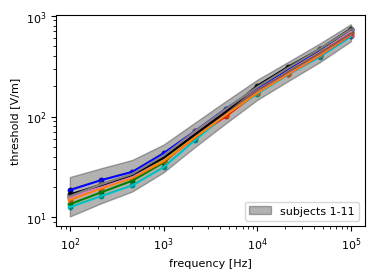

(11, 25, 6, 10, 10)
F_onewayResult(statistic=array([13.22283914, 10.64362487, 15.99416168, 19.84893724, 25.32704017,
       29.77711102, 46.915062  , 51.24166577, 56.41088227, 64.49919325]), pvalue=array([2.06904323e-023, 3.22520310e-018, 4.71782663e-029, 5.75403398e-037,
       2.74794392e-048, 1.61849090e-057, 4.05277242e-093, 4.28933079e-102,
       8.38428108e-113, 1.60262172e-129]))
(11, 25, 6, 10, 10)
subject, cell, orientation, frequency
(7, 22, 3, 1) 178.45790345323607
(4, 22, 5, 1) 162.87675329910167
(0, 22, 3, 1) 124.80177717908
(4, 22, 5, 0) 118.92805688175238
(8, 22, 3, 0) 100.20186275628002
(3, 5, 0, 0) 94.29227449837929
(3, 5, 3, 0) 93.25263779197256
(3, 8, 3, 1) 90.47137627360982
(3, 8, 0, 2) 89.61465431592848
(3, 8, 0, 1) 89.4362069910578
(1650, 10)
(10,)


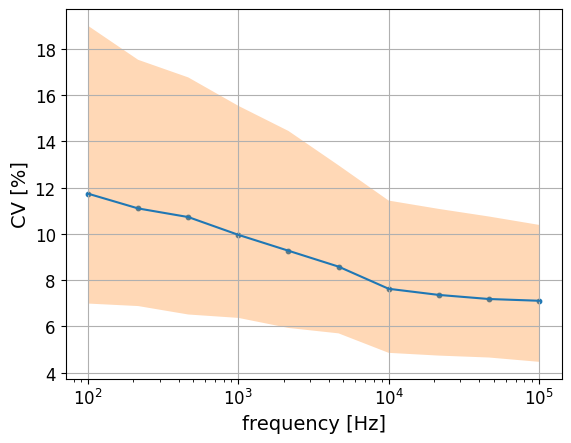

[9.093618931848322, 9.3181887813051, 9.286206025246925, 8.422362915064, 8.15854454264374, 11.183410124293026, 11.725652297976808, 10.378469430774942, 11.004797881312376, 14.271274945280313, 7.068381119925169, 6.448846152468306, 6.186180339063057, 6.692691510282033, 6.869676976526939, 8.995388433525132, 8.46045116659349, 9.521257856422222, 8.959426872609818, 7.543828910596277, 9.581080659684947, 8.016195529366037, 9.702552390354356, 8.57497332740942, 9.79587212990327]
[ 337.76203921  318.81236041  309.7335266   366.89257685  517.02366121
 1826.88842681  715.58725253 1474.83760126 2389.43277344 1668.54520305
  851.44538328  984.86286589  803.76856537  642.81726423  924.53814986
 1359.46713467 1141.1308724  1393.69992925 1113.25030353 1431.65449774
 1048.57880004  985.65771713 1295.82902229  955.71907249  923.34567165]


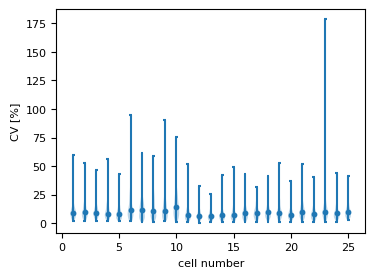

PearsonRResult(statistic=0.44263401283651155, pvalue=0.026707893357155087)
SignificanceResult(statistic=0.3884615384615384, pvalue=0.05498318521785998)


In [ ]:
"""subject variations"""

cells = [cel for cel in range(1,26)]
subjects = [3,7,12,17,18,19,20,21,22,23,24]
ages = [29,28,37,25,28,31,28,32,29,27,27]
genders = [0,1,0,1,0,0,0,1,0,1,1] #M:0, F:1
directions = ['lateral', 'superior', 'anterior'] + ['medial', 'inferior', 'posterior']
#cells = [1,2,3,4,5,6,7,8,9,10,11,15,16,20,21,22,23,24,25] #cells[0:5] + cells[5:10] + cells[10:11] + cells[15:16] + cells[20:25] #[1,2,3,4,5], [6,7,8,9,10], [11,12,13,14,15], [16,17,18,19,20], [21,22,23,24,25]
len_loc = 10
len_freq = 10

colors = ['b','g','r','c','m','y','tab:orange','tab:pink','tab:brown','k', 'tab:gray']
#colors = ['b','y','r','g','c']
type1, type2, type3, type4, type5 = "L1 NGC-DA", "L2/3 PC", "L4 LBC", "L5 TTPC", "L6 TPC"
cell_names = [type1]*5 + [type2]*5 + [type3]*5 + [type4]*5 + [type5]*5
i = 0

all_freqs, all_threshs = np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq)), np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq)) #directions, locations*subjects, frequencies
#all_freqs, all_threshs = np.empty((len(cells),len(directions),len(subjects),len_loc,len_freq)), np.empty((len(cells),len(directions),len(subjects),len_loc,len_freq)) #directions, locations*subjects, frequencies


for isub, subject in enumerate(subjects):
    freqs, threshs = np.empty((len(cells),len(directions),len_loc,len_freq)), np.empty((len(cells),len(directions),len_loc,len_freq))
    for ic,cell in enumerate(cells): 
        for id,direction in enumerate(directions): 
            with open(rf"results\FEM\interpol_linear_logspace_(10, 2, 5)_cell_nr_{cell}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                pkl = pickle.load(f)
            hs300 = pkl['hotspot_300']
            hs100k = pkl['hotspot_100k']

            if sum(hs300[0]['location']==hs100k[0]['location']) == 3:
                for iloc,val300 in enumerate(hs300.values()): #10 locations
                    freq = val300['freq']
                    thresh = val300['thresh']/np.sqrt(2) #peak->RMS
                    freqs[ic,id,iloc] = freq 
                    threshs[ic,id,iloc] = thresh
            else:
                for iloc, (val300, val100k) in enumerate(zip(hs300.values(),hs100k.values())): #10 locations
                    freq = val300['freq']
                    thresh = np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2) #peak->RMS
                    freqs[ic,id,iloc] = freq
                    threshs[ic,id,iloc] = thresh
    all_freqs[isub] = freqs #id
    all_threshs[isub] = threshs
    threshs_flat = threshs.reshape(-1,10)
    qmin = np.quantile(threshs_flat,1/4,axis=0)
    q50 = np.quantile(threshs_flat,2/4,axis=0)
    qmax = np.quantile(threshs_flat,3/4,axis=0)

    plt.scatter(freq,q50,c = colors[i],s=10)
    plt.plot(freq,q50,color = colors[i]) #,color='r'#,label=f's{i+1}'
    #plt.fill_between(freq,qmin,qmax,alpha=0.3,color = colors[i]) #,label=f'25-75 ({subject})'
    i+=1

threshs_flat = all_threshs.reshape(-1,10)
qmin = np.quantile(threshs_flat,1/4,axis=0)
q50 = np.quantile(threshs_flat,2/4,axis=0)
qmax = np.quantile(threshs_flat,3/4,axis=0)

plt.fill_between(freq,qmin,qmax,alpha=0.3,color='k',label='subjects 1-11') #,label=f'25-75 ({celltypes[ict]})'

#plot_guidelines()
plt.grid()
plt.xlabel('frequency [Hz]',fontsize = 8)
plt.ylabel('threshold [V/m]',fontsize = 8)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.xscale('log')
plt.yscale('log')
plt.grid() 
plt.legend(loc='lower right',fontsize=8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)

fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()

"""final plot combining all plots"""

print(all_threshs.shape)

s3 = (all_threshs[0]).reshape(-1, 10)
s7 = (all_threshs[1]).reshape(-1, 10)
s12 = (all_threshs[2]).reshape(-1, 10)
s17 = (all_threshs[3]).reshape(-1, 10)
s18 = (all_threshs[4]).reshape(-1, 10)
s19 = (all_threshs[5]).reshape(-1, 10)
s20 = (all_threshs[6]).reshape(-1, 10)
s21 = (all_threshs[7]).reshape(-1, 10)
s22 = (all_threshs[8]).reshape(-1, 10)
s23 = (all_threshs[9]).reshape(-1, 10)
s24 = (all_threshs[10]).reshape(-1, 10)



ANOVA = f_oneway(s3,s7,s12,s17,s18,s19,s20,s21,s22,s23,s24,axis=0)
print(ANOVA)

"violin plots"
violin = 0
if violin:
    for fr in range(10):
        violins = []
        for i,e in enumerate([s3,s7,s12,s17,s18,s19,s20,s21,s22,s23,s24]):
            violin = e[:,fr]
            violins += [violin]
            plt.scatter(i+1,np.median(violin))
            print(f"subject: {subjects[i]}, mini: {np.min(violin)}, maxi: {np.max(violin)}, maxi/mini = {np.max(violin)/np.min(violin)}")
        maxmin = [np.max(e)/np.min(e) for e in violins]
        medians =  [np.median(e) for e in violins]
        mins = [np.min(e) for e in violins]
        print(medians)
        sorted_medians = np.argsort(medians) + 1
        sorted_mins = np.argsort(mins) + 1
        print(f"sorted medians: {sorted_medians}")
        print(f"sorted mins: {sorted_mins}")
        print(f"median_{sorted_medians[-1]}/median_{sorted_medians[0]} = {medians[np.argsort(medians)[-1]]} / {medians[np.argsort(medians)[0]]} = {medians[np.argsort(medians)[-1]] / medians[np.argsort(medians)[0]]}")
        print(f"sorted maxi/mini: {np.flip(np.argsort(maxmin))+1}")
        plt.violinplot(violins)
        plt.yscale('log')
        plt.xticks([e for e in range(12)])
        plt.grid()
        plt.title(f'frequency = {np.round(freq[fr])} Hz')
        plt.show()

"gender vs threshold"
gender = 0
if gender:
    for fr in range(10):
        violins = []
        males = []
        females = []
        for i,e in enumerate([s3,s7,s12,s17,s18,s19,s20,s21,s22,s23,s24]):
            violin = e[:,fr]
            violins += [violin]
            plt.scatter(genders[i],np.median(violin))#np.max(violin)/np.min(violin)
            if genders[i] == 0:
                males += [violin]
            else:
                females += [violin]
        plt.yscale('log')
        #plt.xticks([1,2,3],['lateral','superior','anterior'])
        plt.xlabel("gender [M/F]",fontsize=12)
        plt.ylabel("threshold [V/m]",fontsize=12)
        plt.grid()
        plt.title(f'frequency = {freq[fr]} Hz')
        plt.show()
        mwu = mannwhitneyu(np.array(males).flatten(),np.array(females).flatten())
        print(mwu)
        U = mwu.statistic
        n1 = 6*1500
        n2 = 5*1500
        Z = (U-(n1*n2)/2)/(np.sqrt(n1*n2*((n1+n2)-1)/12))
        r = Z/np.sqrt((n1+n2))
        print(f'r = {r}')
        plt.violinplot([np.array(males).flatten(),np.array(females).flatten()])
        print(f'np.median(males)/np.median(females) = {np.median(males)/np.median(females)}')
        print()
        plt.scatter([1,2],[np.median(males),np.median(females)])
        plt.grid()
        plt.show()

        # Compute quantiles
        prob = np.linspace(0, 1, 200)
        qx = np.quantile(np.array(males).flatten(), prob)
        qy = np.quantile(np.array(females).flatten(), prob)

        # Plot
        plt.scatter(qx, qy)
        plt.plot([qx.min(), qx.max()], [qx.min(), qx.max()], 'r--')  # 45° reference line
        plt.xlabel("Quantiles of sample X")
        plt.ylabel("Quantiles of sample Y")
        plt.title("Q–Q Plot (Two Samples)")
        plt.show()


"age vs threshold"
age = 0
if age:
    for fr in range(10):
        violins = []
        all_ages = []
        all_threshs_age = []
        for i,e in enumerate([s3,s7,s12,s17,s18,s19,s20,s21,s22,s23,s24]):
            violin = e[:,fr]
            violins += [violin]
            plt.scatter(ages[i],np.median(violin))#np.max(violin)/np.min(violin)
            all_ages += [ages[i]]*len(violin)
            all_threshs_age += [violin]
        plt.yscale('log')
        #plt.xticks([1,2,3],['lateral','superior','anterior'])
        plt.xlabel("age [years]",fontsize=12)
        plt.ylabel("threshold [V/m]",fontsize=12)
        plt.grid()
        plt.title(f'frequency = {freq[fr]} Hz')
        plt.show()
        print(len(all_ages),len(all_threshs_age))
        print(pearsonr(np.array(all_ages).flatten(),np.array(all_threshs_age).flatten()))
        

"coefficient of variation for different locations"
print(all_threshs.shape)
all_CV = variation(all_threshs,axis=3)
CV = all_CV.reshape(-1,10) *100 #%
nmax = 10
argmaxima = CV.flatten().argsort()[-nmax:][::-1]
maxima = np.sort(CV.flatten())[-nmax:][::-1]
print('subject, cell, orientation, frequency')
for i in range(nmax):
    print(np.unravel_index(argmaxima[i], all_CV.shape),maxima[i])
print(CV.shape)
qmin = np.quantile(CV,1/4,axis=0)
q50 = np.quantile(CV,2/4,axis=0)
qmax = np.quantile(CV,3/4,axis=0)
print(qmin.shape)
plt.scatter(freq,q50,s=10)
plt.plot(freq,q50) #,color='r'#,label=f's{i+1}'
plt.fill_between(freq,qmin,qmax,alpha=0.3) #,label=f'25-75 ({celltypes[ict]})'
plt.grid()
plt.xlabel('frequency [Hz]',fontsize = 14)
plt.ylabel('CV [%]',fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xscale('log')
#plt.yscale('log')
plt.show()

import numpy as np


radius = np.array([
    337.762039212467,318.81236040546696,309.73352659585123,366.8925768522078,517.023661214206,1826.8884268142322,715.5872525289243,1474.8376012570247,2389.4327734430963,1668.5452030517579,
    851.445383279299,984.8628658947885,803.7685653743152,642.8172642254723,924.5381498600883,1359.4671346742518,1141.1308723983502,1393.6999292452338,1113.2503035255124,1431.654497738479,
    1048.5788000369996,985.6577171298719,1295.829022293519,955.7190724941131,923.3456716452804
])

violins = []
q50 = [] #cells
#for fr in range(10):
for fr in range(25): #cells
    CVt = np.swapaxes(all_CV,1,3).reshape(-1,25)*100 #cells
    #violins += [CV[:,fr]]
    violins += [CVt[:,fr]] #cells
    q50 += [np.median(CVt[:,fr])] #cells
plt.violinplot(violins)
print(q50)
print(radius)
plt.scatter([e for e in range(1,26)],q50,s=10,c='tab:blue')
#plt.plot([e for e in range(1,26)],q50,c='tab:blue')
# plt.xscale('log')
#plt.xticks([e for e in range(1,11)], [f'{(fre/1e3):.1f}' for fre in freq][:-1]+[100],fontsize = 8)
#plt.xticks([e for e in range(1,4)], ['lateral','superior','anterior'],fontsize = 12)
#plt.xlabel('cells',fontsize = 14)
plt.xticks(fontsize=8)
plt.yticks(fontsize = 8)
#plt.xlabel('frequency [kHz]',fontsize = 8)
plt.xlabel('cell number',fontsize = 8)
plt.ylabel('CV [%]',fontsize = 8)
#plt.yscale('log')
#plt.grid()

fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()

print(pearsonr(q50,radius))
print(spearmanr(q50,radius))

2228.4240365936357 168.52840848371207
100.0
F statistic = MSb/MSw, p-value, Mean Square between, Mean Square within
13.222839144113845 1.1102230246251565e-16 2228.4240365936357 168.52840848371207
2228.4240365936357 / 168.52840848371207 = 13.222839144113845
large F: significant difference between groups, otherwise no detectable difference


5674.159905860786 533.1040859258179
215.443469
F statistic = MSb/MSw, p-value, Mean Square between, Mean Square within
10.643624867377873 1.1102230246251565e-16 5674.159905860786 533.1040859258179
5674.159905860786 / 533.1040859258179 = 10.643624867377873
large F: significant difference between groups, otherwise no detectable difference


4398.702409454743 275.0192536833886
464.15888336
F statistic = MSb/MSw, p-value, Mean Square between, Mean Square within
15.994161683380455 1.1102230246251565e-16 4398.702409454743 275.0192536833886
4398.702409454743 / 275.0192536833886 = 15.994161683380455
large F: significant difference between groups, otherwise n

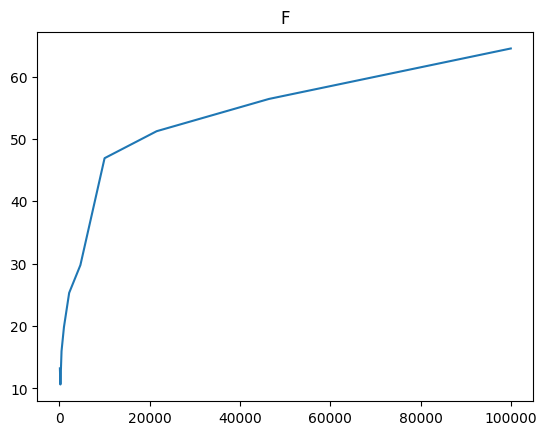

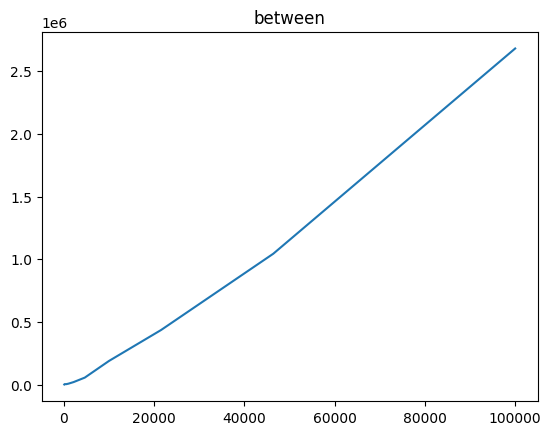

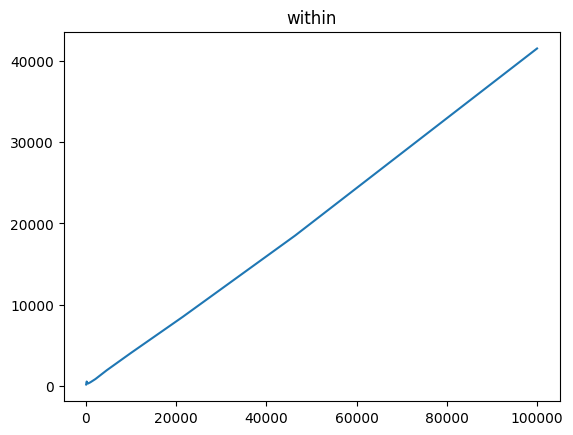

2228.42403659364 168.52840848371198
100.0
var_subject, var_within, icc: intraclass correclation
1.373263752073285 168.52840848371198 0.00808269709180675


5674.159905860786 533.1040859258184
215.443469
var_subject, var_within, icc: intraclass correclation
3.427370546623312 533.1040859258184 0.006388014170049608


4398.702409454743 275.0192536833884
464.15888336
var_subject, var_within, icc: intraclass correclation
2.74912210384757 275.0192536833884 0.009897174565161199


8439.166880932198 425.1697095963053
1000.0
var_subject, var_within, icc: intraclass correclation
5.342664780890595 425.1697095963053 0.012410014435983642


21193.4187533072 836.7901900100195
2154.43469003
var_subject, var_within, icc: intraclass correclation
13.571085708864787 836.7901900100195 0.015959200043995384


56894.55034843531 1910.6806668639554
4641.58883361
var_subject, var_within, icc: intraclass correclation
36.65591312104757 1910.6806668639554 0.018823614519339983


189598.85428152207 4041.3216178101657
10

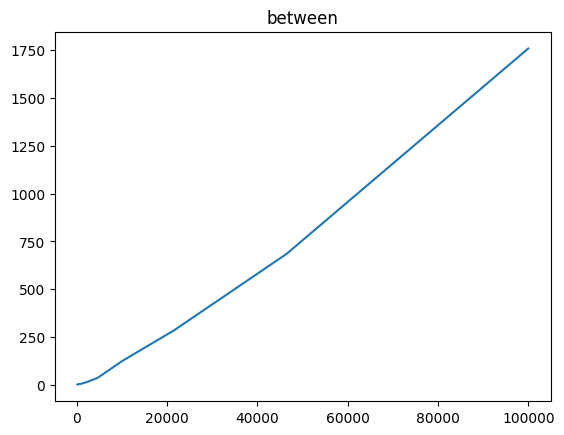

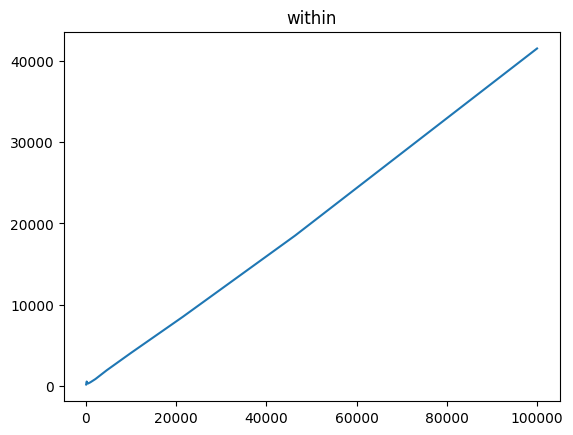

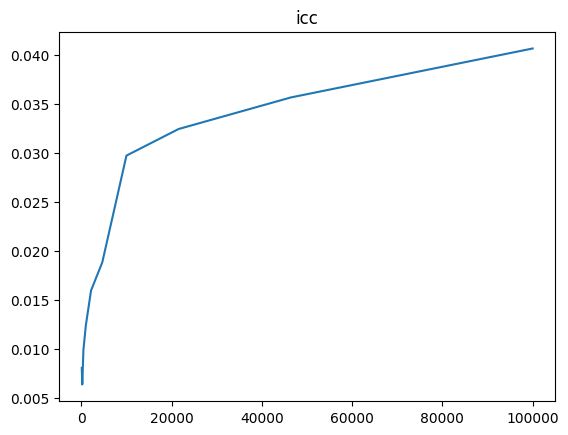

In [7]:
import numpy as np
import pandas as pd

s3 = (all_threshs[0])
s7 = (all_threshs[1])
s12 = (all_threshs[2])
s17 = (all_threshs[3])
s18 = (all_threshs[4])
s19 = (all_threshs[5])
s20 = (all_threshs[6])
s21 = (all_threshs[7])
s22 = (all_threshs[8])
s23 = (all_threshs[9])
s24 = (all_threshs[10])

freqs = [100., 215.443469, 464.15888336, 1000., 2154.43469003, 4641.58883361, 10000., 21544.34690032, 46415.88833613, 100000.]

subjects = ["s3","s7","s12","s17","s18","s19","s20","s21","s22","s23","s24"]
dfs = {freq: [] for freq in range(10)}

for subj_name, subj_data in zip(subjects, all_threshs):
    # subj_data: (25, 6, 10, 10)
    for freq in range(10):
        arr = subj_data[:, :, :, freq]  # shape (25,6,10)
        cell_idx, dir_idx, loc_idx = np.indices(arr.shape)

        df = pd.DataFrame({
            "Subject": subj_name,
            "CellType": cell_idx.flatten(),
            "Direction": dir_idx.flatten(),
            "Location": loc_idx.flatten(),
            "Frequency": freq,
            "Threshold": arr.flatten()
        })
        dfs[freq].append(df)

for freq in range(10):
    dfs[freq] = pd.concat(dfs[freq], ignore_index=True)





from scipy.stats import f

def anova_oneway(groups):
    """groups is a list of 1D arrays, one array per level."""
    k = len(groups)
    ns = [len(g) for g in groups]
    N = sum(ns)
    grand_mean = np.mean(np.concatenate(groups))

    ss_between = sum([len(g) * (np.mean(g) - grand_mean)**2 for g in groups])
    ss_within = sum([sum((g - np.mean(g))**2) for g in groups])

    df_between = k - 1
    df_within = N - k

    ms_between = ss_between / df_between
    ms_within = ss_within / df_within

    print(ms_between,ms_within)

    F_value = ms_between / ms_within
    p_value = 1 - f.cdf(F_value, df_between, df_within)

    return F_value, p_value, ms_between, ms_within

Fs, ps, MSbs, MSws = [],[],[],[]
for ifreq,freq in enumerate(freqs):
    df = dfs[ifreq]
    groups = [df[df["Subject"] == s]["Threshold"].values for s in df["Subject"].unique()]
    F, p, MSb, MSw = anova_oneway(groups)
    Fs += [F]
    ps += [p]
    MSbs += [MSb]
    MSws += [MSw]
    print(freq)
    print('F statistic = MSb/MSw, p-value, Mean Square between, Mean Square within')
    print(F, p, MSb, MSw)
    print(f'{MSb} / {MSw} = {F}')
    print('large F: significant difference between groups, otherwise no detectable difference')
    print('\n')

plt.plot(freqs,Fs)
plt.title('F')
plt.show()
plt.plot(freqs,MSbs)
plt.title('between')
plt.show()
plt.plot(freqs,MSws)
plt.title('within')
plt.show()


def variance_components_subject(df):
    # df: single frequency
    subjects = df["Subject"].unique()
    n_within = len(df[df["Subject"] == subjects[0]])  # 1500

    # subject means
    subj_means = df.groupby("Subject")["Threshold"].mean()
    grand_mean = df["Threshold"].mean()

    # SS for subjects
    ss_subject = sum(n_within * (subj_means[s] - grand_mean)**2 for s in subjects)
    df_subject = len(subjects) - 1
    MS_subject = ss_subject / df_subject

    # residual SS
    ss_resid = 0
    for s in subjects:
        vals = df[df["Subject"] == s]["Threshold"].values
        ss_resid += np.sum((vals - np.mean(vals))**2)

    df_resid = len(df) - len(subjects)
    MS_resid = ss_resid / df_resid

    print(MS_subject,MS_resid)

    var_subject = (MS_subject - MS_resid) / n_within
    var_within = MS_resid

    ICC = var_subject / (var_subject + var_within)

    return var_subject, var_within, ICC


var_ss, var_ws, iccs = [],[],[]
for ifreq,freq in enumerate(freqs):
    var_s, var_w, icc = variance_components_subject(dfs[ifreq])
    print(freq)
    print('var_subject, var_within, icc: intraclass correclation')
    print(var_s, var_w, icc)
    var_ss += [var_s]
    var_ws += [var_w]
    iccs += [icc]
    
    print('\n')

plt.plot(freqs,var_ss)
plt.title('between')
plt.show()
plt.plot(freqs,var_ws)
plt.title('within')
plt.show()
plt.plot(freqs,iccs)
plt.title('icc')
plt.show()


(11, 25, 6, 10, 10)
1184.0688473847672
(0, 22, 3, 6)
indices = (0, 22, 3, 6), value = 1184.0688473847672
indices = (0, 22, 3, 7), value = 1136.213305943682
indices = (0, 22, 3, 4), value = 1135.6796010205474
indices = (7, 22, 3, 3), value = 987.9144854643463
indices = (4, 22, 5, 0), value = 759.593165363138
indices = (3, 3, 3, 7), value = 185.99167967935912
indices = (3, 2, 0, 7), value = 181.7363514124254
indices = (3, 2, 3, 7), value = 175.12562737694424
indices = (3, 3, 0, 7), value = 166.44579877130263
indices = (3, 1, 3, 8), value = 165.44377957694823
(16500, 10)
DRL_ICES_unres
[103.77517406  77.33890558  55.51006505  37.91706869  30.00491879
  21.5066918   17.06704623  12.75857034  10.44776988   8.52366877]
[11.5305749   8.59321173  6.16778501  4.21300763  3.33387987  2.38963242
  1.89633847  1.41761893  1.16086332  0.94707431]
DRL_ICES_res
[34.53309464 25.7359409  18.4719934  12.61760082  9.98468767  7.15674659
  5.67937301  4.24564855  3.47668726  2.83640729]
[11.51103155  8.57

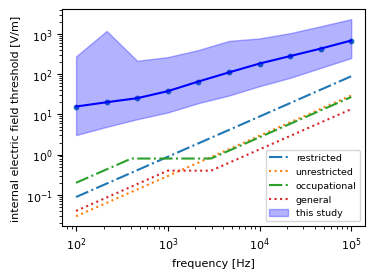

(16500, 10)
freq_fact: [ 3.          1.39247665  0.64633041  0.3         0.13924767  0.06463304
 10.          4.64158883  2.15443469  1.        ]
DRL_ICES_unres
[68.88763789 51.33881558 36.84847841 33.12030074 56.46577657 62.95583722
 52.87005942 39.52332249 32.36495682 26.40450305]
[7.65418199 5.70431284 4.09427538 3.68003342 6.27397517 6.99509302
 5.87445105 4.39148028 3.59610631 2.93383367]
DRL_ICES_res
[22.97949249 17.125568   12.29189095 11.04545952 18.83106238 20.98527907
 17.62335314 13.17444083 10.78831894  8.80150102]
[7.65983083 5.70852267 4.09729698 3.68181984 6.27702079 6.99509302
 5.87445105 4.39148028 3.59610631 2.93383367]
BS_ICNIRP_occ_CNS
[ 62.27442466  46.41028928  51.53869309  75.84548869 129.30662834
 129.0594663  108.3836218   81.02281111  66.34816149  54.12923126]
[62.27442466 46.41028928 10.30773862 15.16909774 25.86132567 25.81189326
 21.67672436 16.20456222 13.2696323  10.82584625]
BS_ICNIRP_gen_CNS
[311.37212328 232.05144642 193.27009907 284.42058259 484.89985

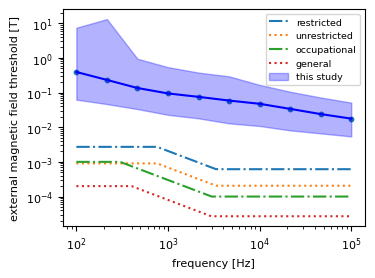

In [ ]:
cells = [cel for cel in range(1,26)]
subjects = [3,7,12,17,18,19,20,21,22,23,24]
directions = ['lateral', 'superior', 'anterior'] + ['medial', 'inferior', 'posterior']
len_loc = 10
len_freq = 10

freq_array = np.logspace(2,5,200) #np.logspace(2,5,200)

#ICES
E0_unres = 5.89*1e-3
E0_res = 1.77*1e-2
DRL_ICES_unres = np.array([E0_unres if freq < 20 else E0_unres*freq/20 for freq in freq_array])
DRL_ICES_res = np.array([E0_res if freq < 20 else E0_res*freq/20 for freq in freq_array])
#ICNIRP
BS_ICNIRP_occ_CNS = np.array([0.5/freq if freq < 10 else 0.05 if freq <25 else 2*1e-3*freq if freq < 400 else 0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
#BS_ICNIRP_occ_PNS = np.array([0.8 if freq < 3*1e3 else 2.7*1e-4*freq for freq in freq_array])
BS_ICNIRP_gen_CNS = np.array([0.1/freq if freq < 10 else 0.01 if freq <25 else 4*1e-4*freq if freq < 1000 else 0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])
#BS_ICNIRP_gen_PNS = np.array([0.4 if freq < 3*1e3 else 1.35*1e-4*freq for freq in freq_array])

#guidelines plotting
plt.loglog(freq_array,DRL_ICES_res,'-.',label='restricted') #occupational
plt.loglog(freq_array,DRL_ICES_unres,':',label='unrestricted') #general
plt.loglog(freq_array,BS_ICNIRP_occ_CNS,'-.',label='occupational') #occupational CNS
#plt.loglog(freq_array,BS_ICNIRP_occ_PNS,'-.',label='ICNIRP_occupational_PNS') #occupational PNS   
plt.loglog(freq_array,BS_ICNIRP_gen_CNS,':',label='general') #occupational CNS
#plt.loglog(freq_array,BS_ICNIRP_gen_PNS,':',label='ICNIRP_general_PNS') #occupational PNS 

all_freqs = np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq))  #directions, locations*subjects, frequencies
all_threshs = np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq))
all_titrs = np.empty((len(subjects),len(cells),len(directions),len_loc,len_freq))
for isub, subject in enumerate(subjects):
    freqs, threshs = np.empty((len(cells),len(directions),len_loc,len_freq)), np.empty((len(cells),len(directions),len_loc,len_freq))
    titrs = np.empty((len(cells),len(directions),len_loc,len_freq))
    for ic,cell in enumerate(cells): 
        for id,direction in enumerate(directions): 
            with open(rf"results\FEM\interpol_linear_logspace_(10, 2, 5)_cell_nr_{cell}_dt_fact_100_subject_{subject}_direction_{direction}.pkl",'rb') as f:
                pkl = pickle.load(f)
            hs300 = pkl['hotspot_300']
            hs100k = pkl['hotspot_100k']

            if sum(hs300[0]['location']==hs100k[0]['location']) == 3:
                for iloc,val300 in enumerate(hs300.values()): #10 locations
                    freq = val300['freq']
                    thresh = val300['thresh']/np.sqrt(2)
                    titr = val300['titr']/np.sqrt(2)*1e-3 #1mT
                    freqs[ic,id,iloc] = freq 
                    threshs[ic,id,iloc] = thresh
                    titrs[ic,id,iloc] = titr
            else:
                for iloc, (val300, val100k) in enumerate(zip(hs300.values(),hs100k.values())): #10 locations
                    freq = val300['freq']
                    thresh = np.min((val300['thresh'], val100k['thresh']),axis=0)/np.sqrt(2)
                    titr = np.min((val300['titr'], val100k['titr']),axis=0)/np.sqrt(2)*1e-3 #1mT
                    freqs[ic,id,iloc] = freq
                    threshs[ic,id,iloc] = thresh
                    titrs[ic,id,iloc] = titr
    all_freqs[isub] = freqs #id
    all_threshs[isub] = threshs
    all_titrs[isub] = titrs
print(all_threshs.shape)
print(np.max(all_threshs[:,:,:,:,1]))
print(np.unravel_index(np.argmax(all_threshs[:,:,:,:,1]), (11, 25, 6, 10)))

arr = all_threshs[:, :, :, :, 1]
# Flatten the array
flat = arr.ravel()
# Find indices of the top 10 largest values (unsorted)
idx_top10 = np.argpartition(flat, -10)[-10:]
# Sort these indices by actual value (largest → smallest)
idx_top10_sorted = idx_top10[np.argsort(flat[idx_top10])[::-1]]
# Convert back to multi-dimensional coordinates
coords_top10 = np.array(np.unravel_index(idx_top10_sorted, arr.shape)).T
# Get the corresponding values
values_top10 = flat[idx_top10_sorted]
# Print results
for coord, val in zip(coords_top10, values_top10):
    print(f"indices = {tuple(coord)}, value = {val}")

threshs_flat = all_threshs.reshape(-1,10)
print(threshs_flat.shape)
qmin = np.quantile(threshs_flat,0/4,axis=0)
q50 = np.quantile(threshs_flat,2/4,axis=0)
qmax = np.quantile(threshs_flat,4/4,axis=0)

guidelines = give_guidelines(CNS=1)
for guideline, name, fr in zip(guidelines, ['DRL_ICES_unres','DRL_ICES_res','BS_ICNIRP_occ_CNS','BS_ICNIRP_gen_CNS'], freq):
    #print(f' min_thresh/{name}: \n= {min_thresh/guideline}')
    print(name)
    sf = [safety_factor(name,fr) for fr in freq]
    print((qmin/guideline))
    print((qmin/guideline/sf))
    #print(np.sum((min_thresh/guideline/sf)<1))

plt.scatter(freq,q50,s=10)
plt.plot(freq,q50,color='b') #,color='r'
plt.fill_between(freq,qmin,qmax,alpha=0.3,label=f'this study',color='b')

#plot_guidelines()
plt.xlabel('frequency [Hz]',fontsize = 8)
plt.ylabel('internal electric field threshold [V/m]',fontsize = 8)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.xscale('log')
plt.yscale('log')
#plt.grid() 
plt.legend(loc='lower right',fontsize=6.8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)

fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()






freq_array = np.logspace(2,5,200) #np.logspace(2,5,200)

#ICES
DRL_ICES_unres = np.array([118 if freq < 0.153 else 18.1/freq if freq < 20 else 0.904 if freq < 751 else 687/freq if freq < 3.35*1e3 else 0.205 for freq in freq_array])*1e-3 #mT -> T
DRL_ICES_res = np.array([353 if freq < 0.153 else 54.3/freq if freq < 20 else 2.71 if freq < 751 else 2060/freq if freq < 3.35*1e3 else 0.615 for freq in freq_array])*1e-3 #mT -> T
#ICNIRP
BS_ICNIRP_occ_CNS = np.array([0.2/freq**2 if freq < 8 else 2.5*1e-2/freq if freq < 25 else 1*1e-3 if freq < 300 else 0.3/freq if freq < 3*1e3 else 1e-4 for freq in freq_array])
BS_ICNIRP_gen_CNS = np.array([4*1e-2/freq**2 if freq < 8 else 5*1e-3/freq if freq < 25 else 2*1e-4 if freq < 400 else 8*1e-2/freq if freq < 3*1e3 else 2.7*1e-5 for freq in freq_array])

#guidelines plotting
plt.loglog(freq_array,DRL_ICES_res,'-.',label='restricted') #occupational
plt.loglog(freq_array,DRL_ICES_unres,':',label='unrestricted') #general
plt.loglog(freq_array,BS_ICNIRP_occ_CNS,'-.',label='occupational') #occupational CNS
#plt.loglog(freq_array,BS_ICNIRP_occ_PNS,'-.',label='ICNIRP_occupational_PNS') #occupational PNS   
plt.loglog(freq_array,BS_ICNIRP_gen_CNS,':',label='general') #occupational CNS
#plt.loglog(freq_array,BS_ICNIRP_gen_PNS,':',label='ICNIRP_general_PNS') #occupational PNS 


titrs_flat = all_titrs.reshape(-1,10)
print(titrs_flat.shape)
qmin = np.quantile(titrs_flat,0/4,axis=0)
q50 = np.quantile(titrs_flat,2/4,axis=0)
qmax = np.quantile(titrs_flat,4/4,axis=0)

freq_fact = np.array([300/fr if fr < 10000 else 100000/fr for fr  in freq])
print(f'freq_fact: {freq_fact}')

guidelines = give_guidelines_ext(CNS=1)
for guideline, name, fr in zip(guidelines, ['DRL_ICES_unres','DRL_ICES_res','BS_ICNIRP_occ_CNS','BS_ICNIRP_gen_CNS'], freq):
    #print(f' min_thresh/{name}: \n= {min_thresh/guideline}')
    print(name)
    sf = [safety_factor(name,fr) for fr in freq]
    print((qmin*freq_fact/guideline))
    print((qmin*freq_fact/guideline/sf))
    #print(np.sum((min_thresh/guideline/sf)<1))

plt.scatter(freq,q50*freq_fact,s=10)
plt.plot(freq,q50*freq_fact,color='b') #,color='r'
plt.fill_between(freq,qmin*freq_fact,qmax*freq_fact,alpha=0.3,label=f'this study',color='b')

#plot_guidelines()
plt.xlabel('frequency [Hz]',fontsize = 8)
plt.ylabel('external magnetic field threshold [T]',fontsize = 8)
plt.xticks(fontsize = 8)
plt.yticks(fontsize = 8)
plt.xscale('log')
plt.yscale('log')
#plt.grid() 
plt.legend(loc='upper right',fontsize=6.8)
#plt.title(f'cells: {cells}, subjects: {subjects}, directions: {directions} exposure, 10 closest locations',fontsize=8)

fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()

*---------*
Loaded Blue Brain cell: L23_PC_cADpyr229_2
Got main axon (method 2)
Myelinating axon: Replacing 48 Axonal sections w/ 84 Myelin, 84 Node, 11 Unmyelin sections
Adding myelin before the 1st bifurcation
Scaled diameter of myelin sections using variable g-ratio
Inserted xtra and extracellular in all 610 compartments
Got main axon (method 2)
Cell Loaded
loading trimesh
loaded trimesh


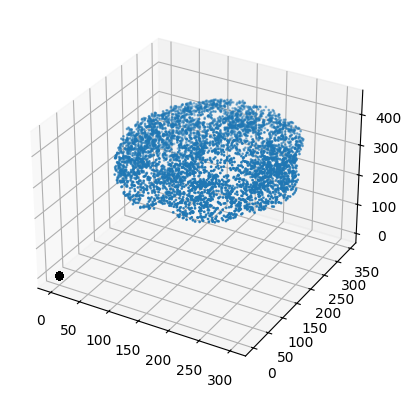

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
h("NSTACK_size = 10000")
h.load_file('init.hoc')
h.load_file('thresh4.hoc') 
h.load_file('get_es2.hoc') #for TMS
h.load_file('interp_coordinates.hoc') #for TMS (to calc Dx,Dy and Dz)

cell_nr = 7
h.setParamsAdultHuman() #this needs to go before the cell chooser, otherwise it won't make a difference
h.cell_chooser(cell_nr)

subject = 3
meshname = 'layer_1_depth_0.06' if cell_nr < 6 else 'layer_23_depth_0.40' if cell_nr < 11 else 'layer_4_depth_0.55' if cell_nr < 16 else 'layer_5_depth_0.65' if cell_nr < 21 else 'layer_6_depth_0.85' if cell_nr <26 else 'ERROR'
print('loading trimesh')
surface_mesh = trimesh.load_mesh(rf"tissue_meshes\subjects\s{subject}\layers\{meshname}.stl")


points = surface_mesh.sample(5000)


# vertices = surface_mesh.vertices
# faces = surface_mesh.faces

print('loaded trimesh')

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

for sec in h.allsec():
    for seg in sec:
        if 'Scale' in str(seg):
            continue
        ax.scatter(seg.x_xtra*1e-3,seg.y_xtra*1e-3,seg.z_xtra*1e-3,color='k')

ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1)

plt.show()

[ 20.  26.  34.  45.  58.  76. 100. 131. 171. 224. 292. 382. 500.]


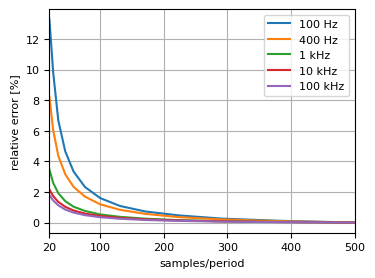

In [ ]:
"effect of dt"

import pickle
import matplotlib.pyplot as plt
convergences = np.empty((5,13))
dt_facts = np.round(np.logspace(np.log10(20),np.log10(500),13))
freq_dict = {100.0 : '100 Hz', 400.0 : '400 Hz', 1000.0 : '1 kHz', 10000.0 : '10 kHz', 100000.0 : '100 kHz'}
print(dt_facts)
with open(r"results\FEM\convergence_dt_fact_interpol_linear_cell_nr_7_subject_3_direction_lateral.pkl",'rb') as f:
    convergence = pickle.load(f)
for idt, dt_fact in enumerate(dt_facts):
    convergences[:,idt] = convergence['hotspot_300'][dt_fact]['thresh']
for it,threshs in enumerate(convergences):
    convergences[it] = ((threshs - threshs[-1])/threshs[-1])*100 #in percent
    #plt.plot(dt_facts,convergences[it],label=f"{convergence['hotspot_300'][dt_fact]['freq'][it]:.0e} Hz")
    plt.plot(dt_facts,convergences[it],label=f"{freq_dict[convergence['hotspot_300'][dt_fact]['freq'][it]]}")
fs = 8
plt.xlabel("samples/period",fontsize=fs)
plt.ylabel("relative error [%]",fontsize=fs)
plt.xticks(list(plt.xticks()[0][2:-1])+[20],fontsize=fs)
#plt.xticks(dx_array,fontsize=fs,minor=True)
plt.xlim((20,500))
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.legend(fontsize=fs)
plt.grid()


fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()

[ 0.1  0.2  0.5  1.   2.   5.  10.  20.  50. ]


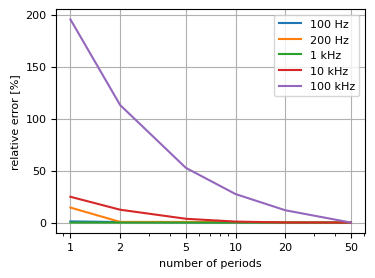

In [ ]:
%matplotlib inline
import matplotlib
"effect of duration"

import pickle
import matplotlib.pyplot as plt
convergences = np.empty((5,9))
dur_facts = np.outer(np.logspace(-1,1,3),[1,2,5]).flatten()
freq_dict = {100.0 : '100 Hz', 200.0 : '200 Hz', 1000.0 : '1 kHz', 10000.0 : '10 kHz', 100000.0 : '100 kHz'}
print(dur_facts)
with open(r"results\FEM\convergence_dur_fact_interpol_linear_cell_nr_7_subject_3_direction_lateral.pkl",'rb') as f:
    convergence = pickle.load(f)
for idur, dur_fact in enumerate(dur_facts):
    convergences[:,idur] = convergence['hotspot_300'][dur_fact]['thresh']
for it,threshs in enumerate(convergences):
    convergences[it] = ((threshs - threshs[-1])/threshs[-1])*100 #in percent
    #plt.plot(dt_facts,convergences[it],label=f"{convergence['hotspot_300'][dt_fact]['freq'][it]:.0e} Hz")
    plt.plot(dur_facts[3:],convergences[it][3:],label=f"{freq_dict[convergence['hotspot_300'][dur_fact]['freq'][it]]}")
fs = 8
plt.xlabel("number of periods",fontsize=fs)
plt.ylabel("relative error [%]",fontsize=fs)
plt.xticks(dur_facts[3:])
#plt.xticks(list(plt.xticks()[0][2:-1])+[20],fontsize=fs)
#plt.xticks(dx_array,fontsize=fs,minor=True)
#plt.xlim((20,500))
#plt.yscale('log')
plt.xscale('log')
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.legend(fontsize=fs)
plt.grid()


fig = plt.gcf()
ax = fig.get_axes()
#ax[0].set_xscale('log')
ax[0].set_xticks([1, 2, 5,10,20,50])
ax[0].get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()

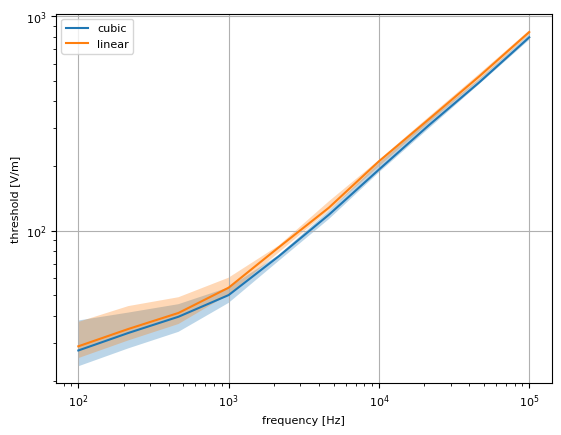

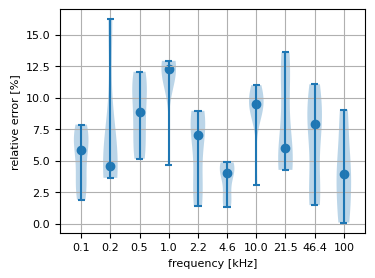

16.198381192967993 6.905629088336034
[[ 7.85689563  7.38769761  6.98969524  6.48222102  6.37485638  5.27837005
   3.76154617  3.23003845  2.33799809  1.89537788]
 [ 4.26806032  3.92192383  3.6334491   4.1603075  16.13974659 16.19838119
   6.70218629  6.04947905  4.24093071  4.89324788]
 [12.04636803 11.54162434 11.21495327 10.82327246  9.3685469   8.37209302
   7.50517396  6.07780768  5.20610734  5.14535436]
 [ 4.63507205 11.51383827 12.18446753 12.1995094  12.5065474  12.91480741
  12.23098075 12.27980952 12.48923836 12.56334536]
 [ 8.9490476   8.51174663  8.18606275  7.76431892  7.92443307  6.28267491
   4.00841625  2.83589231  1.78406309  1.36262421]
 [ 1.90795681  1.59508478  1.35876403  4.17756738  4.56232131  4.86097758
   2.88257736  3.85786802  4.48300016  4.70334557]
 [ 3.09489443  9.51003148  9.26272568  9.24471618  9.45814343  9.74641457
   9.40933822  9.75456544 10.49461886 10.98472769]
 [ 4.45565364  4.31782258  4.26563257 11.51763575 13.33678335 13.58466038
  10.62319658 

In [ ]:
"cubic"
with open(r"results\FEM\interpol_cubic_logspace_(10, 2, 5)_cell_nr_7_dt_fact_100_subject_3_direction_lateral.pkl",'rb') as f:
    cubic_results = pickle.load(f)

hs300c = cubic_results['hotspot_300']
hs100kc = cubic_results['hotspot_100k']

freqsc,threshsc = np.empty((10,10)), np.empty((10,10))

if sum(hs300c[0]['location']==hs100kc[0]['location']) == 3:
    for iloc,val300c in enumerate(hs300c.values()): #10 locations
        freqc = val300c['freq']
        threshc = val300c['thresh']/np.sqrt(2) #peak->RMS
        threshsc[iloc] = threshc
else:
    for iloc, (val300c, val100kc) in enumerate(zip(hs300c.values(),hs100kc.values())): #10 locations
        freqc = val300c['freq']
        threshc = np.min((val300c['thresh'], val100kc['thresh']),axis=0)/np.sqrt(2) #peak->RMS
        threshsc[iloc] = threshc
"linear"

with open(r"results\FEM\interpol_linear_logspace_(10, 2, 5)_cell_nr_7_dt_fact_100_subject_3_direction_lateral.pkl",'rb') as f:
    linear_results = pickle.load(f)

hs300l = linear_results['hotspot_300']
hs100kl = linear_results['hotspot_100k']

freqsl,threshsl = np.empty((10,10)), np.empty((10,10))

if sum(hs300l[0]['location']==hs100kl[0]['location']) == 3:
    for iloc,val300l in enumerate(hs300l.values()): #10 locations
        freql = val300l['freq']
        threshl = val300l['thresh']/np.sqrt(2) #peak->RMS
        threshsl[iloc] = threshl
else:
    for iloc, (val300l, val100kl) in enumerate(zip(hs300l.values(),hs100kl.values())): #10 locations
        freql = val300l['freq']
        threshl = np.min((val300l['thresh'], val100kl['thresh']),axis=0)/np.sqrt(2) #peak->RMS
        threshsl[iloc] = threshl

plt.plot(freq,np.median(threshsc,axis=0),label='cubic')
plt.fill_between(freq,np.percentile(threshsc,25,axis=0),np.percentile(threshsc,75,axis=0),alpha=0.3)
plt.plot(freq,np.median(threshsl,axis=0),label='linear')
plt.fill_between(freq,np.percentile(threshsl,25,axis=0),np.percentile(threshsl,75,axis=0),alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("frequency [Hz]",fontsize=8)
plt.ylabel("threshold [V/m]",fontsize=8)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.legend(fontsize=8)
plt.grid()
plt.show()



threshs_diff = np.empty((10,10))
violins = []
q50 = []

for it, (tc, tl) in enumerate(zip(threshsc,threshsl)):
    #print(tc,tl)
    #assume cubic as ground truth
    tdiff = np.abs(tl-tc)/tc*100 #in %
    threshs_diff[it] = tdiff
    violins += [tdiff]
    q50 += [np.median(tdiff)]
plt.violinplot(violins)
plt.scatter([e+1 for e in range(10)],q50)
# plt.boxplot(violins,positions=freq)
plt.xlabel("frequency [kHz]",fontsize=8)
plt.ylabel("relative error [%]",fontsize=8)
plt.xticks([e+1 for e in range(10)],[f"{f/1e3:.1f}" for f in freq][:-1]+[100],fontsize=8)
plt.yticks(fontsize=8)
plt.grid()
plt.tight_layout()

fig = plt.gcf()
x_size, y_size = fig.get_size_inches()
fig.set_size_inches(7.7/2,7.7*y_size/(2*x_size))
fig.tight_layout()
plt.show()

print(np.max(violins), np.mean(violins))
print(threshs_diff)



In [ ]:
# Load your mesh
mesh = trimesh.load_mesh(r"tissue_meshes\layers\layer_1_depth_0.06.stl")  # Replace with your layer file

# Get AABB
aabb_min, aabb_max = mesh.bounds
print("Axis-Aligned Bounding Box:")
print(f"Min corner: {aabb_min}")
print(f"Max corner: {aabb_max}")


Axis-Aligned Bounding Box:
Min corner: [ 22.85766792  30.67272758 238.88066101]
Max corner: [305.07791138 348.12884521 449.15988159]


45
0 44
['Environment'] ['scalp']


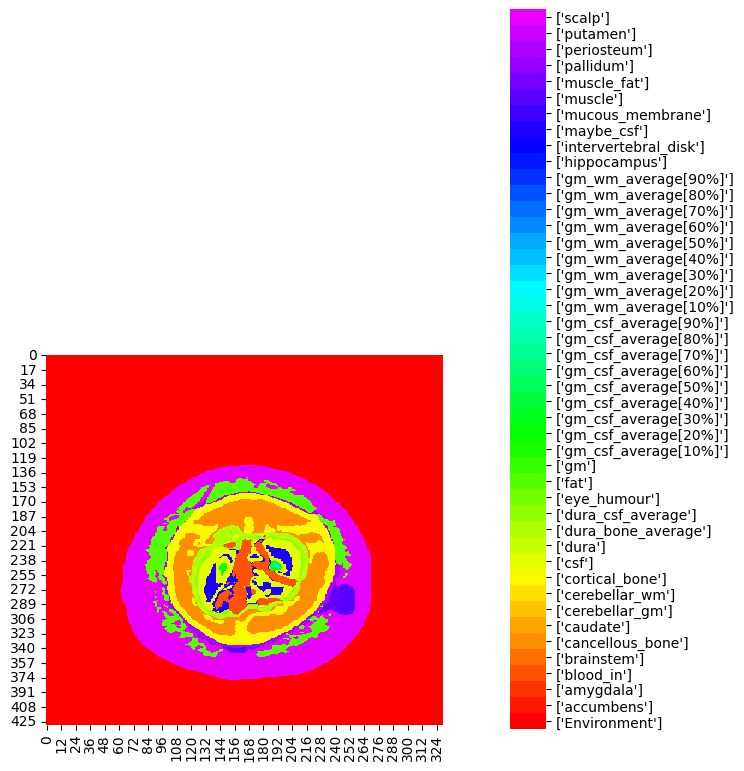

In [ ]:

from matplotlib.colors import ListedColormap

brainmap_slice = brainmap[:,:,449] #159,87,323

# for i,e in enumerate(brainmap_slice):
#     for j,f in enumerate(e):
#         if f not in [16,26,27,28,29,30,31,32,33,34,49]:
#             brainmap_slice[i,j] = 0 

Emaglat_slice = Emaglat[:,:,449]
scatterp = (159,323) #(87,323) #sagittal
tissuefirst,tissuelast = np.min(brainmap_slice), np.max(brainmap_slice)
tn = tissuelast-tissuefirst+1 #tissue numbers
colors = plt.colormaps['hsv'](np.linspace(0, 1, tn+int(0.2*tn)))[:tn]
cmap = ListedColormap(colors)
print(tn)
print(tissuefirst,tissuelast)
print(braintissuess[tissuefirst], braintissuess[tissuelast])

ax = sb.heatmap(np.rot90(brainmap_slice), linecolor='lightgray',cmap=cmap)
#plt.scatter(scatterp[0],488-scatterp[1],color='purple',s=20) #sagittal
colorbar = ax.collections[0].colorbar
colorbar.ax.set_position([0.85, 0.1, 0.3, 1.5])
dx = ((tn-1)/tn)/2
ticks = np.linspace(dx+tissuefirst,tissuelast-dx,tn)
colorbar.set_ticks(ticks)
colorbar.set_ticklabels(braintissuess[tissuefirst:tissuelast+1])
plt.show()

0.22592907


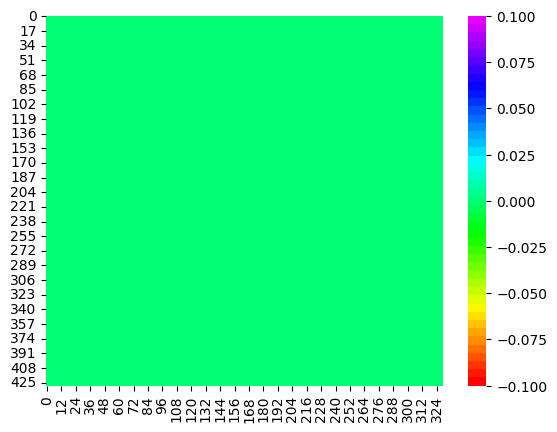

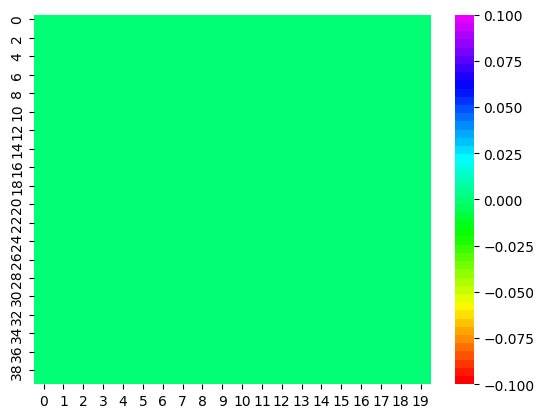

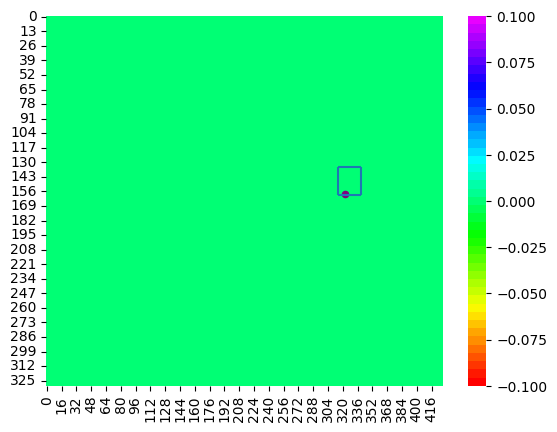

0.0
(0, 0)


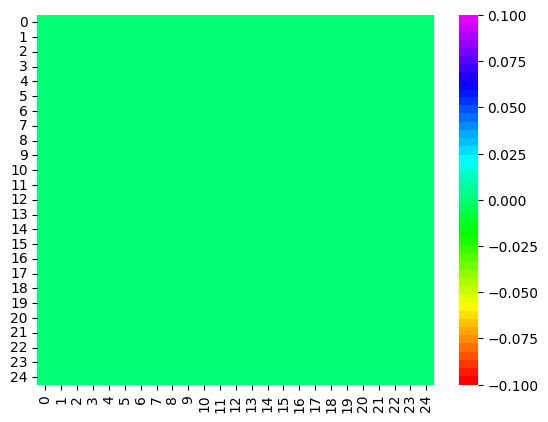

In [ ]:
print((Emaglat[:,:,:]*(brainmap[:,:,:]==16))[159,87,323])
ax = sb.heatmap(np.rot90(Emaglat_slice*(brainmap_slice==16)), linecolor='lightgray',cmap=cmap)
#plt.scatter(scatterp[0],488-scatterp[1],color='purple',s=20) #sagittal
plt.show()
ax = sb.heatmap(np.rot90(Emaglat_slice*(brainmap_slice==16))[330:370, 150:170], linecolor='lightgray',cmap=cmap)
#plt.scatter(scatterp[0],488-scatterp[1],color='purple',s=20) #sagittal
plt.show()

ax = sb.heatmap((Emaglat_slice*(brainmap_slice==16)), linecolor='lightgray',cmap=cmap)
left, right, top, bottom = 315,340, 135,160
plt.vlines(left,bottom,top)
plt.vlines(right,bottom,top)
plt.hlines(bottom,left,right)
plt.hlines(top,left,right)
#plt.scatter(159,87,color='purple',s=20) #sagittal
plt.scatter(323,159,color='purple',s=20)
plt.show()

print(np.max((Emaglat_slice*(brainmap_slice==16))[top:bottom,left:right])) #[50:100,140:180] #[50:100,:]
print(np.unravel_index(np.argmax((Emaglat_slice*(brainmap_slice==16))[top:bottom,left:right]),Emaglat_slice.shape))
ax = sb.heatmap((Emaglat_slice*(brainmap_slice==16))[top:bottom,left:right], linecolor='lightgray',cmap=cmap)
#plt.scatter(87-80,159-130,color='purple',s=20) #sagittal
plt.show()

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import Normalize


sh = (brainmap==16).shape
x_val, y_val, z_val = np.zeros((sh[0],sh[1])), np.zeros((sh[0],sh[1])), np.zeros((sh[0],sh[1]))
for i,e in enumerate(brainmap):
    for j,f in enumerate(e):
        x_val[i,j] = i
        y_val[i,j] = j
        z_val[i,j] = np.argmax(brainmap[i][j]*np.arange(sh[2]))
print(np.max(z_val[i,j]))
print(x_val.shape,y_val.shape,z_val.shape)

x = 70
values = np.linspace(0, x, x)  # 50 values between 0 and x

# Create a normalization object
norm = Normalize(vmin=0, vmax=x)

# Choose a colormap (e.g., 'viridis')
cmap = cm.get_cmap('viridis')

# Map values to colors
colors = cmap(norm(values))
print(colors)

0.0
(330, 429) (330, 429) (330, 429)
[[0.267004 0.004874 0.329415 1.      ]
 [0.271305 0.019942 0.347269 1.      ]
 [0.276022 0.044167 0.370164 1.      ]
 [0.279566 0.067836 0.391917 1.      ]
 [0.281446 0.08432  0.407414 1.      ]
 [0.28291  0.105393 0.426902 1.      ]
 [0.283187 0.125848 0.44496  1.      ]
 [0.282623 0.140926 0.457517 1.      ]
 [0.280868 0.160771 0.472899 1.      ]
 [0.278012 0.180367 0.486697 1.      ]
 [0.274128 0.199721 0.498911 1.      ]
 [0.270595 0.214069 0.507052 1.      ]
 [0.265145 0.232956 0.516599 1.      ]
 [0.258965 0.251537 0.524736 1.      ]
 [0.253935 0.265254 0.529983 1.      ]
 [0.246811 0.283237 0.535941 1.      ]
 [0.239346 0.300855 0.540844 1.      ]
 [0.231674 0.318106 0.544834 1.      ]
 [0.225863 0.330805 0.547314 1.      ]
 [0.21813  0.347432 0.550038 1.      ]
 [0.210503 0.363727 0.552206 1.      ]
 [0.204903 0.375746 0.553533 1.      ]
 [0.197636 0.391528 0.554969 1.      ]
 [0.190631 0.407061 0.556089 1.      ]
 [0.183898 0.422383 0.55694

C:\Users\jgazquez\AppData\Local\Temp\ipykernel_24188\2785472750.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


C:\Users\jgazquez\AppData\Local\Temp\ipykernel_22384\3443486112.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis')


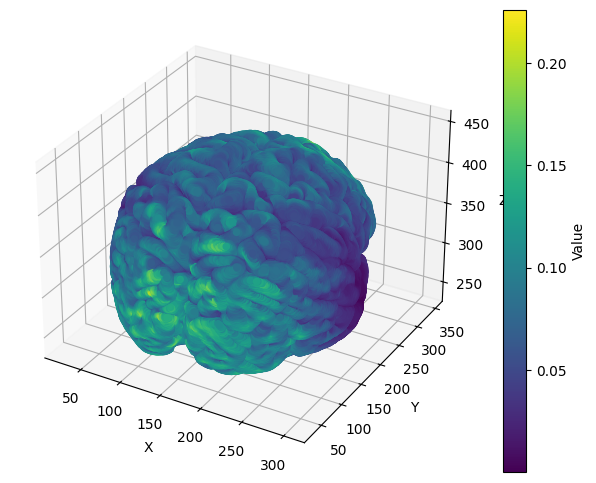

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

# Example 3D matrix
matrix = Emaglat*(brainmap==16)

# Get coordinates and values
x_idx, y_idx, z_idx = np.indices(matrix.shape)
x = x_idx.flatten()
y = y_idx.flatten()
z = z_idx.flatten()
values = matrix.flatten()

# Filter out zeros
mask = values != 0
x = x[mask]
y = y[mask]
z = z[mask]
values = values[mask]

# Normalize and colormap
norm = Normalize(vmin=values.min(), vmax=values.max())
cmap = cm.get_cmap('viridis')

# Scatter plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
sc = ax.scatter(x, y, z, c=values, cmap=cmap, norm=norm, s=20)

# Colorbar
fig.colorbar(sc, ax=ax, label='Value')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

In [ ]:
import numpy as np
import plotly.graph_objects as go

# Example 3D matrix
matrix = Emaglat*(brainmap==16)

# Get coordinates and values
x_idx, y_idx, z_idx = np.indices(matrix.shape)
x = x_idx.flatten()
y = y_idx.flatten()
z = z_idx.flatten()
values = matrix.flatten()

# Filter non-zero values
mask = values != 0
x, y, z, values = x[mask], y[mask], z[mask], values[mask]

# Create interactive scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=4,
        color=values,
        colorscale='Viridis',
        colorbar=dict(title='Value'),
        opacity=0.8
    )
)])
fig.update_layout(scene=dict(
    xaxis_title='X',
    yaxis_title='Y',
    zaxis_title='Z'
))
fig.show()